In [139]:
%load_ext autoreload
%autoreload 2
from reward_relative.path_dict_seahorse import path_dictionary as path_dict
from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import spatial
from reward_relative import placeCellPlot
from reward_relative import dayData as dd
from reward_relative import behavior
import pickle
import dill
import numpy as np
import os 
import matplotlib.pyplot as plt
import TwoPUtils
import protter_functions as pf
from scipy.signal import medfilt
from matplotlib.lines import Line2D
import pandas as pd
import umap
import hdbscan
import importlib
import scipy.interpolate as interp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
licks_na_free = np.load('protter_tmp_files/all_licks_na_dropped.npy')
trials_na_free = pd.read_csv('protter_tmp_files/new_all_licks_na_dropped_trial_info.csv')

In [3]:
from sklearn import decomposition as skd

lick_pca = skd.PCA()
transform = lick_pca.fit_transform(licks_na_free)

In [4]:
transform.shape

(6222, 45)

pct_total = [sum(lick_pca.explained_variance_[:i+1]/lick_pca.explained_variance_.sum()) for i in range(transform.shape[1])]
lick_pca.explained_variance_/lick_pca.explained_variance_.sum()
fig, ax = plt.subplots()
ax.plot(pct_total, 'o')

In [5]:
trials_na_free

,Unnamed: 0,idx,day,trial,reward_zone_start,reward_zone_end,swap_zone_start,swap_zone_end,trial_type,swap_type,omit,animal
0,0,0,3,0,320,370,80.0,130.0,pre_swap,swap_proximal,False,GCAMP3
1,1,1,3,1,320,370,80.0,130.0,pre_swap,swap_proximal,False,GCAMP3
2,2,2,3,2,320,370,80.0,130.0,pre_swap,swap_proximal,False,GCAMP3
3,3,3,3,3,320,370,80.0,130.0,pre_swap,swap_proximal,False,GCAMP3
4,4,4,3,4,320,370,80.0,130.0,pre_swap,swap_proximal,False,GCAMP3
...,...,...,...,...,...,...,...,...,...,...,...,...
6217,75,6280,14,75,80,130,320.0,370.0,post_swap,swap_proximal,False,GCAMP19
6218,76,6281,14,76,80,130,320.0,370.0,post_swap,swap_proximal,True,GCAMP19
6219,77,6282,14,77,80,130,320.0,370.0,post_swap,swap_proximal,True,GCAMP19
6220,78,6283,14,78,80,130,320.0,370.0,post_swap,swap_proximal,False,GCAMP19


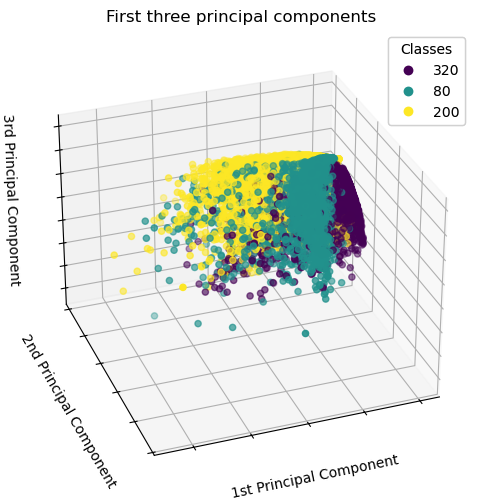

In [6]:
import mpl_toolkits.mplot3d 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)
scatter = ax.scatter(
    transform[:, 0],
    transform[:, 1],
    transform[:, 2],
    c=trials_na_free.reward_zone_start,
   
)

ax.set(
    title="First three principal components",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    trials_na_free.reward_zone_start.unique().tolist(),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend1)

In [7]:
def get_licks_at_location(licks, loc, bins):
    '''loc = [start, end]'''
    st, en = np.searchsorted(bins, loc)
    return {'licks':licks[:,st:en], 'bin_centers':bins[st:en]}


In [8]:
def get_lick_features(licks, bins_centers,  meta, norm = True):
    ''''''
    n_licks = licks.sum(axis = 1)

    rzone_1_start = meta.reward_zone_start.values[0]
    rzone_2_start = meta.reward_zone_start.values[-1]
    

    rzone_1_end = meta.reward_zone_end.values[0]
    rzone_2_end = meta.reward_zone_end.values[-1]

    rzone_1 = [rzone_1_start, rzone_1_end]
    rzone_2 = [rzone_2_start, rzone_2_end]

    rzone_1_trials = meta.reward_zone_start == rzone_1_start
    rzone_2_trials = meta.reward_zone_start == rzone_2_start
    

    at_zone = np.zeros_like(n_licks)
    at_other_zone = np.zeros_like(n_licks)
    after_zone = np.zeros_like(n_licks)
    after_other_zone = np.zeros_like(n_licks)
    before_zone = np.zeros_like(n_licks)
    before_other_zone = np.zeros_like(n_licks)

    
    at_zone[rzone_1_trials] = get_licks_at_location(licks[rzone_1_trials], rzone_1, bin_centers)['licks'].sum(axis = 1)
    at_zone[rzone_2_trials] = get_licks_at_location(licks[rzone_2_trials], rzone_2, bin_centers)['licks'].sum(axis = 1)

    at_other_zone[rzone_1_trials] = get_licks_at_location(licks[rzone_1_trials], rzone_2, bin_centers)['licks'].sum(axis = 1)
    at_other_zone[rzone_2_trials] = get_licks_at_location(licks[rzone_2_trials], rzone_1, bin_centers)['licks'].sum(axis = 1)

    after_zone[rzone_1_trials] = get_licks_at_location(licks[rzone_1_trials], [rzone_1_end, rzone_1_end + 30], bin_centers)['licks'].sum(axis = 1)
    after_zone[rzone_2_trials] = get_licks_at_location(licks[rzone_2_trials], [rzone_2_end, rzone_2_end + 30], bin_centers)['licks'].sum(axis = 1)

    after_other_zone[rzone_1_trials] = get_licks_at_location(licks[rzone_1_trials], [rzone_2_end, rzone_2_end + 30], bin_centers)['licks'].sum(axis = 1)
    after_other_zone[rzone_2_trials] = get_licks_at_location(licks[rzone_2_trials], [rzone_1_end, rzone_1_end + 30], bin_centers)['licks'].sum(axis = 1)

    before_zone[rzone_1_trials] = get_licks_at_location(licks[rzone_1_trials], [rzone_1_start - 50, rzone_1_start], bin_centers)['licks'].sum(axis = 1)
    before_zone[rzone_2_trials] = get_licks_at_location(licks[rzone_2_trials], [rzone_2_start - 50, rzone_2_start], bin_centers)['licks'].sum(axis = 1)

    before_other_zone[rzone_1_trials] = get_licks_at_location(licks[rzone_1_trials], [rzone_2_start - 50, rzone_2_start], bin_centers)['licks'].sum(axis = 1)
    before_other_zone[rzone_2_trials] = get_licks_at_location(licks[rzone_2_trials], [rzone_1_start - 50, rzone_1_start], bin_centers)['licks'].sum(axis = 1)

    feature_set = [n_licks, at_zone/n_licks, at_other_zone/n_licks, after_zone/n_licks, after_other_zone/n_licks, before_zone/n_licks, before_other_zone/n_licks]

    if norm:
        feature_norm = [feat/n_licks for feat in feature_set[1:]]
        feature_set = [n_licks]+feature_norm     
   
    feature_arr = np.zeros((len(licks), len(feature_set)))
    for i, feat in enumerate(feature_set):
        feature_arr[:,i] = feat

    
    return np.nan_to_num(feature_arr)



In [9]:
licks_na_free[:2,:].sum(axis = 1)

array([15.7622549 ,  4.08333333])

In [10]:
display_slicer = (trials_na_free.animal == 'GCAMP12') 
bin_centers = np.arange(5,455,10)
feats = get_lick_features(licks_na_free[display_slicer], bin_centers, trials_na_free[display_slicer])

In [11]:
get_licks_at_location(licks_na_free, [300,350], bin_centers)['licks'].shape

(6222, 5)

In [12]:
sum(display_slicer)

559

In [13]:
trials_na_free.loc[display_slicer]

,Unnamed: 0,idx,day,trial,reward_zone_start,reward_zone_end,swap_zone_start,swap_zone_end,trial_type,swap_type,omit,animal
2316,0,2365,3,0,200,250,320.0,370.0,pre_swap,swap_distal,False,GCAMP12
2317,1,2366,3,1,200,250,320.0,370.0,pre_swap,swap_distal,False,GCAMP12
2318,2,2367,3,2,200,250,320.0,370.0,pre_swap,swap_distal,False,GCAMP12
2319,3,2368,3,3,200,250,320.0,370.0,pre_swap,swap_distal,False,GCAMP12
2320,4,2369,3,4,200,250,320.0,370.0,pre_swap,swap_distal,False,GCAMP12
...,...,...,...,...,...,...,...,...,...,...,...,...
2870,75,2920,14,75,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP12
2871,76,2921,14,76,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP12
2872,77,2922,14,77,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP12
2873,78,2923,14,78,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP12


In [14]:
rzone_start_to_name = {80:'A', 200:'B', 320:'C'}
rzone_dict = {'A':[80, 130], 'B':[200, 250], 'C':[320, 370]}


In [15]:
from dataclasses import dataclass

@dataclass
class Zone:

    name:'str'
    start: int
    end: int
    anticipatory_distance: int = 50
    post_zone_distance: int = 20

    def __post_init__(self):
        self.anticipatory_zone = [self.start-self.anticipatory_distance, self.start]
        self.rzone = [self.start, self.end]
        self.after_zone = [self.end, self.end+self.post_zone_distance]


class DayZones:

    def __init__(self, meta_slice, anticipatory_distance = 50, post_zone_distance = 20):
        self.rzone_dict = {'A':[80, 130], 'B':[200, 250], 'C':[320, 370]}
        self.meta = meta_slice
        rzone_1_start = self.meta.reward_zone_start.values[0]
        rzone_2_start = self.meta.reward_zone_start.values[-1]

        rzone_1_end = self.meta.reward_zone_end.values[0]
        rzone_2_end = self.meta.reward_zone_end.values[-1]
        
        self.pre_zone = Zone(name = rzone_start_to_name[rzone_1_start],
                             start = rzone_1_start,
                             end = rzone_1_end,
                             anticipatory_distance = anticipatory_distance, 
                             post_zone_distance = post_zone_distance)
        
        self.post_zone = Zone(name = rzone_start_to_name[rzone_2_start],
                             start = rzone_2_start,
                             end = rzone_2_end,
                             anticipatory_distance = anticipatory_distance, 
                             post_zone_distance = post_zone_distance)
        
        self.pre_trials = self.meta.reward_zone_start == rzone_1_start
        self.post_trials = self.meta.reward_zone_start == rzone_2_start

        self.unused_zone_name = [v for v in self.rzone_dict.keys() if not v in [self.pre_zone.name, self.post_zone.name]][0]
        self.unused_zone = Zone(name = self.unused_zone_name,
                                start = self.rzone_dict[self.unused_zone_name][0],
                                end = self.rzone_dict[self.unused_zone_name][1],
                                anticipatory_distance = anticipatory_distance, 
                                post_zone_distance = post_zone_distance)


def get_licks_from_zone_object(licks, zone_object, bin_centers):
    return {'at_zone':get_licks_at_location(licks, zone_object.rzone, bin_centers)['licks'].sum(axis = 1),
            'anticipatory_zone':get_licks_at_location(licks, zone_object.anticipatory_zone, bin_centers)['licks'].sum(axis = 1),
            'after_zone':get_licks_at_location(licks, zone_object.after_zone, bin_centers)['licks'].sum(axis = 1),}


def generate_zone_lick_features_from_class(licks, day_zone_obj, bin_centers, norm = False, reward_relative = True):
    n_licks = licks.sum(axis = 1)
    pre_zone_licks = get_licks_from_zone_object(licks, day_zone_obj.pre_zone, bin_centers)
    post_zone_licks = get_licks_from_zone_object(licks, day_zone_obj.post_zone, bin_centers)
    other_zone_licks = get_licks_from_zone_object(licks, day_zone_obj.unused_zone, bin_centers)

    features = {'n_licks':n_licks}
    if reward_relative:
        for key in pre_zone_licks.keys():
            feat = pre_zone_licks[key].copy() #this copy killed me. i was modifying the orig. ndarray
            feat[day_zone_obj.post_trials] = post_zone_licks[key][day_zone_obj.post_trials]
            features[key] = feat

            other_feat = np.zeros_like(feat)

            other_feat[day_zone_obj.post_trials] = pre_zone_licks[key][day_zone_obj.post_trials]
            other_feat[day_zone_obj.pre_trials] = post_zone_licks[key][day_zone_obj.pre_trials]

            features[key+'_other'] = other_feat

            features[key+'_third_zone'] = other_zone_licks[key]
    else:
        for key in pre_zone_licks.keys():
            feat = pre_zone_licks[key].copy() #this copy killed me. i was modifying the orig. ndarray
            
            features[key + '_pre'] = feat

            feat = post_zone_licks[key].copy() #this copy killed me. i was modifying the orig. ndarray
                        
            features[key + '_post'] = feat

            features[key+'_third_zone'] = other_zone_licks[key]

    
    features['start'] = get_licks_at_location(licks, [0, 30], bin_centers)['licks'].sum(axis = 1)
    features['end'] = get_licks_at_location(licks, [400, 450], bin_centers)['licks'].sum(axis = 1)


    features_df = pd.DataFrame.from_dict(features)
    if norm:
        features_df = features_df/n_licks[:,np.newaxis]
        features_df['n_licks'] = n_licks
    
    return features_df
    # return features
    

    


# def generate_zone_lick_features_from_class(licks, day_zone_obj):

#     n_licks = licks.sum(axis = 1)

#     at_zone = np.zeros_like(n_licks)
#     at_other_zone = np.zeros_like(n_licks)
#     after_zone = np.zeros_like(n_licks)
#     after_other_zone = np.zeros_like(n_licks)
#     before_zone = np.zeros_like(n_licks)
#     before_other_zone = np.zeros_like(n_licks)

    
#     at_zone[day_zone_obj.pre_trials] = get_licks_at_location(licks[day_zone_obj.pre_trials], day_zone_obj.pre_zone.rzone, bin_centers)['licks'].sum(axis = 1)
#     at_zone[day_zone_obj.post_trials] = get_licks_at_location(licks[day_zone_obj.post_trials], day_zone_obj.post_zone.rzone, bin_centers)['licks'].sum(axis = 1)

#     at_other_zone[day_zone_obj.pre_trials] = get_licks_at_location(licks[day_zone_obj.pre_trials], day_zone_obj.post_zone.rzone, bin_centers)['licks'].sum(axis = 1)
#     at_other_zone[day_zone_obj.post_trials] = get_licks_at_location(licks[day_zone_obj.post_trials], day_zone_obj.pre_zone.rzone, bin_centers)['licks'].sum(axis = 1)

#     after_zone[day_zone_obj.pre_trials] = get_licks_at_location(licks[day_zone_obj.pre_trials], day_zone_obj.pre_trials.after_zone, bin_centers)['licks'].sum(axis = 1)
#     after_zone[day_zone_obj.post_trials] = get_licks_at_location(licks[day_zone_obj.post_trials], day_zone_obj.post_trials.after_zone, bin_centers)['licks'].sum(axis = 1)

#     after_other_zone[day_zone_obj.pre_trials] = get_licks_at_location(licks[day_zone_obj.pre_trials], day_zone_obj.post_trials.after_zone, bin_centers)['licks'].sum(axis = 1)
#     after_other_zone[day_zone_obj.post_trials] = get_licks_at_location(licks[day_zone_obj.post_trials], day_zone_obj.pre_trials.after_zone, bin_centers)['licks'].sum(axis = 1)

#     before_zone[day_zone_obj.pre_trials] = get_licks_at_location(licks[day_zone_obj.pre_trials], day_zone_obj.pre_trials.anticipatory_zone, bin_centers)['licks'].sum(axis = 1)
#     before_zone[day_zone_obj.post_trials] = get_licks_at_location(licks[day_zone_obj.post_trials], day_zone_obj.post_trials.anticipatory_zone, bin_centers)['licks'].sum(axis = 1)

#     before_other_zone[day_zone_obj.pre_trials] = get_licks_at_location(licks[day_zone_obj.pre_trials], day_zone_obj.post_trials.anticipatory_zone, bin_centers)['licks'].sum(axis = 1)
#     before_other_zone[day_zone_obj.post_trials] = get_licks_at_location(licks[day_zone_obj.post_trials], day_zone_obj.pre_trials.anticipatory_zone, bin_centers)['licks'].sum(axis = 1)

#     feature_set = {'n_licks': n_licks, 
#                    'at_zone':at_zone, 
#                    'at_other_zone':at_other_zone, 
#                    'anticipatory_licks':before_zone, 
#                    'anticipatory_other_licks':before_other_zone, 
#                    'after_zone': after_zone,
#                    'after_other_zone':after_other_zone}

#     if norm:
#         feature_norm = [feat/n_licks for feat in feature_set[1:]]
#         feature_set = [n_licks]+feature_norm     
   
#     feature_arr = np.zeros((len(licks), len(feature_set)))
#     for i, feat in enumerate(feature_set):
#         feature_arr[:,i] = feat

    
#     return np.nan_to_num(feature_arr)
         

    

In [16]:
def generate_cross_day_features(licks, meta, bin_centers, norm = False, reward_relative = True):
    days = meta.day.unique()
    day_slicer = meta.day == days[0]
    day_slice = meta.loc[day_slicer]
    day_zone_obj = DayZones(day_slice)
    features = generate_zone_lick_features_from_class(licks[day_slicer], day_zone_obj, bin_centers, norm = norm, 
                                                      reward_relative=reward_relative)
    sorted_meta = day_slice.copy()
    sorted_licks = licks[day_slicer]
    if len(days) > 1:
        for day in days[1:]:
            day_slicer = meta.day == day
            day_slice = meta.loc[day_slicer]
            day_zone_obj = DayZones(day_slice, post_zone_distance=15)
            feat_day = generate_zone_lick_features_from_class(licks[day_slicer], 
                                                              day_zone_obj, 
                                                              bin_centers, norm = norm,
                                                              reward_relative=reward_relative)
            features = pd.concat([features, feat_day])
            sorted_meta = pd.concat([sorted_meta, day_slice])
            sorted_licks = np.concatenate([sorted_licks, licks[day_slicer]])
    
    return features, sorted_meta, sorted_licks

def hellinger(X):
    """I got this transform from claude to deal with lots of zeros in the data.
    Row-normalize counts to proportions, then sqrt. Undefined for all-zero rows."""
    return np.sqrt(X / X.sum(axis=1)[:,np.newaxis])



In [17]:
feats, sorted_meta, sorted_licks = generate_cross_day_features(licks_na_free[display_slicer], trials_na_free[display_slicer], bin_centers,
                                                               reward_relative=False)

In [18]:
feats

,n_licks,at_zone_pre,at_zone_post,at_zone_third_zone,anticipatory_zone_pre,anticipatory_zone_post,anticipatory_zone_third_zone,after_zone_pre,after_zone_post,after_zone_third_zone,start,end
0,8.238095,0.389533,0.000000,2.486958,2.930651,0.000000,1.171952,0.0,0.071143,0.192218,0.000117,0.471038
1,6.373810,1.063699,0.000000,2.009892,2.317825,0.000000,0.197422,0.0,0.000000,0.249001,0.535971,0.000000
2,5.324074,1.513927,0.000000,0.893285,2.730112,0.000000,0.000000,0.0,0.000000,0.186751,0.000000,0.000000
3,6.630610,1.081978,0.000000,1.085636,2.775522,0.000000,0.000000,0.0,0.000000,1.687475,0.000000,0.000000
4,1.976190,0.872017,0.000000,0.000000,1.104174,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
75,6.769854,0.000000,1.389326,0.000000,0.000000,4.451407,0.000000,0.0,0.000000,0.000000,0.929121,0.000000
76,5.717857,0.000000,0.693639,0.000000,0.000000,4.130801,0.000000,0.0,0.000000,0.000000,0.893417,0.000000
77,4.888172,0.000000,1.338667,0.000000,0.000000,3.549241,0.000000,0.0,0.000000,0.000000,0.000264,0.000000
78,2.545977,0.000000,1.232294,0.000000,0.000000,1.313551,0.000000,0.0,0.000000,0.000000,0.000132,0.000000


In [19]:
import scipy.stats as sts
sts.zscore(feats, axis = 0).shape

(559, 12)

In [20]:
trials_na_free.animal.unique()

array(['GCAMP3', 'GCAMP4', 'GCAMP7', 'GCAMP11', 'GCAMP12', 'GCAMP13',
       'GCAMP14', 'GCAMP15', 'GCAMP17', 'GCAMP18', 'GCAMP19'],
      dtype=object)

[0 5 8 1 3 4 6 7 9 2]


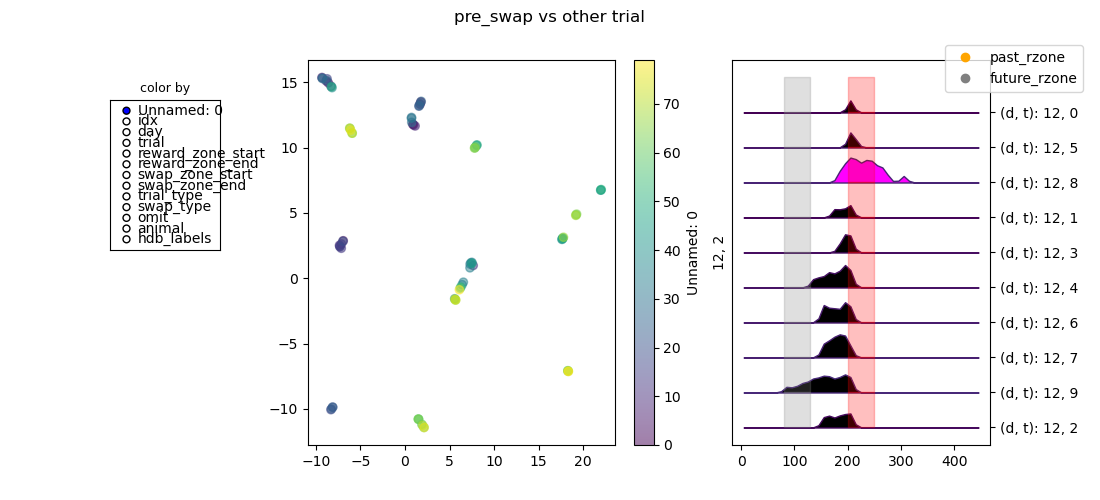

In [21]:
%matplotlib widget
import protter_plot_functions as ppf
ppf = importlib.reload(ppf)
from protter_plot_functions import add_hover, add_color_selector, ColorSelector, ColorSelectorV2#, #add_selectors
from claude_test_space import add_selectors
from protter_plot_functions import TrialPlotLinker

bin_centers = np.arange(5,455,10)

# display_slicer = (trials_na_free.animal == 'GCAMP12')&(trials_na_free.day == 14)

animal = 'GCAMP14'
day = 12

display_slicer = (trials_na_free.animal == animal) &(trials_na_free.day == day)
#
# display_slicer = (trials_na_free.trial_type == 'post_swap')
# display_slicer = [True]*len(licks_na_free)

# feats = get_lick_features(licks_na_free[display_slicer], bin_centers, trials_na_free[display_slicer], norm = False)


features, sorted_meta, sorted_licks = generate_cross_day_features(licks_na_free[display_slicer], 
                                                                  trials_na_free[display_slicer], 
                                                                  bin_centers, norm = False, 
                                                                  reward_relative=False
                                                                  )
feats = features[[c for c in features.columns if not c in [ 'n_licks', ]]]
feats = np.nan_to_num(feats)


reducer = umap.UMAP(n_neighbors=int(sum(display_slicer/22)), min_dist=0)

transform = reducer.fit_transform(feats)


# lick_pca = skd.PCA()
# transform = lick_pca.fit_transform(feats[:,1:])

min_samples = 3
min_cluster_size = 3
new_labels = hdbscan.HDBSCAN(
    min_samples=min_samples,
    min_cluster_size=min_cluster_size,

).fit_predict(transform)


metadata = sorted_meta.copy()
metadata['hdb_labels'] = new_labels


scatter_meta = metadata
scatter_data = transform
linker = TrialPlotLinker(metadata)
raster_data = sorted_licks

fig = plt.figure(figsize = (11,5))
fig.suptitle('pre_swap vs other trial')
axes_dict = fig.subplot_mosaic([['lick_umap', 'lick_umap', 'lick_raster'],
                                    ['lick_umap','lick_umap', 'lick_raster'],
                                    ],
                                height_ratios = [3.0,2.0],
                                width_ratios = [2.0,2.0,3])

ax_umap= axes_dict['lick_umap']




scatter_1 = ax_umap.scatter(scatter_data[:,0], scatter_data[:,1], alpha = 0.5, label = 'preswap')

ax_umap.legend()


add_hover(scatter_1, scatter_meta)
color_selector = ColorSelectorV2(scatter_1,scatter_meta)

sel = add_selectors(scatter_1, linker, scatter_meta)


umap_view = ppf.ScatterView(data = transform, meta = scatter_meta, plt_obj = scatter_1)


lick_ax = axes_dict['lick_raster']
lick_ax.tick_params(right=True, labelright=True, left=False, labelleft=False)

raster_view = ppf.LickRasterView(raster_data, bin_centers, scatter_meta, lick_ax)
raster_view.link_colormaps(color_selector.get_color_linker(), )
raster_view.sort_by({'hdb_labels':'descending', 'reward_zone_start':'descending','day':'descending', 'trial':'ascending'})
color_selector.add_after_recolor_call(raster_view.update_linked_colors)

linker.add_views([umap_view, raster_view]) 
# raster_view.update(start_idx)
# umap_view.update(start_idx)


In [22]:
features[sorted_meta.trial.isin([28,30]).values]

,n_licks,at_zone_pre,at_zone_post,at_zone_third_zone,anticipatory_zone_pre,anticipatory_zone_post,anticipatory_zone_third_zone,after_zone_pre,after_zone_post,after_zone_third_zone,start,end
28,1.366667,1.220823,0.000000,0.0,0.145843,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
30,3.100000,0.000000,0.000422,0.0,1.563897,0.0,0.0,0.0,1.535681,0.0,0.0,0.0


In [23]:
features.loc[metadata.trial.isin([44,71]).values]

,n_licks,at_zone_pre,at_zone_post,at_zone_third_zone,anticipatory_zone_pre,anticipatory_zone_post,anticipatory_zone_third_zone,after_zone_pre,after_zone_post,after_zone_third_zone,start,end
44,14.950000,0.0,1.369704,5.96766,0.0,0.163629,3.372444,0.106715,0.0,2.451864,0.0,0.160512
71,3.845238,0.0,1.418201,0.00000,0.0,2.427037,0.000000,0.000000,0.0,0.000000,0.0,0.000000


KeyboardInterrupt: 

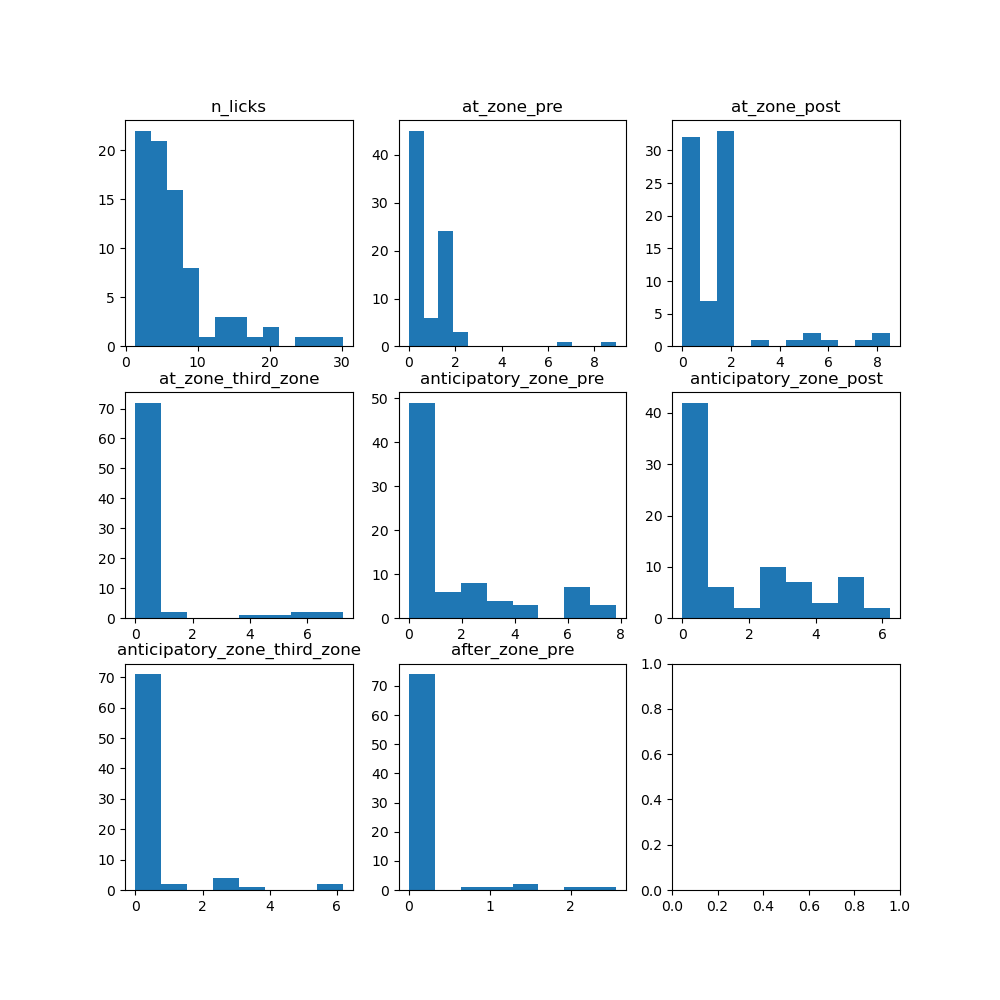

In [24]:
fig, axs = plt.subplots(3,3, figsize = (10,10))
for ax, col in zip(axs.ravel(), features.columns):
    ax.hist(features[col], bins = 'auto')
    ax.set_title(col)

In [25]:
def get_reward_zone_outliers(cluster_column_name, value, meta):

    meta_slice = meta.loc[meta[cluster_column_name] == value]

    rzones = meta_slice['reward_zone_start'].value_counts()
    
    if len(rzones)>1:
        return meta_slice
    else:
        return None
    
outliers = {}

    
for day in metadata.day.unique():
    ani_slice = metadata.loc[(metadata.day == day)]
    for i in range( metadata.hdb_labels.max()+1 ):
        out = get_reward_zone_outliers('hdb_labels', i, ani_slice)
        if not out is None:
            if day in outliers.keys():

                outliers[day][i] = out
           
            else:
                outliers = {day:{i:out}}

for day in outliers.keys():
    print(f'----------- day {day}')
    for label in outliers[day].keys():
        print(f'------------------ label {label}: {len(outliers[day][label])}')

----------- day 12
------------------ label 4: 6
------------------ label 9: 10
------------------ label 12: 6


In [26]:
def sum_outliers(animal_dict):
    tot = 0
    for d in animal_dict.keys():
        tot += len(animal_dict[d].keys())
    return tot



In [27]:
ppf = importlib.reload(ppf)
def make_outlier_rasters(animal, outlier_dict, data, metadata_df):
    bin_centers = np.arange(5,455,10)
    num_plots = sum_outliers(outlier_dict[animal])

    cols = 4
    rows = int(np.ceil(num_plots/cols))

    fig, axs = plt.subplots(ncols = cols, nrows = rows, figsize = (10, 3*rows))

    loc = 0

    for d, labels in outlier_dict[animal].items():
        for l, df in labels.items():
            dat = data[metadata_df['idx'].isin(df.idx.values)]
            v = ppf.LickRasterView(dat, bin_centers, df, axs.ravel()[loc], starting_selection=df.idx.values)
            loc+=1
            v.plt_obj.set_title(f'label: {l} d: {d}')
            
            v.plt_obj.set_yticklabels([f"tr {row[1]}" for row in df[['day','trial']].values], rotation = 90)
    
    fig.suptitle(animal)
            


In [28]:
ppf = importlib.reload(ppf)
def plot_raster_from_licks( data, metadata_df, ax, starting_selection = -1):
    bin_centers = np.arange(5,455,10)



    v = ppf.LickRasterView(data, bin_centers, metadata_df, ax, starting_selection = starting_selection)

    
    
    


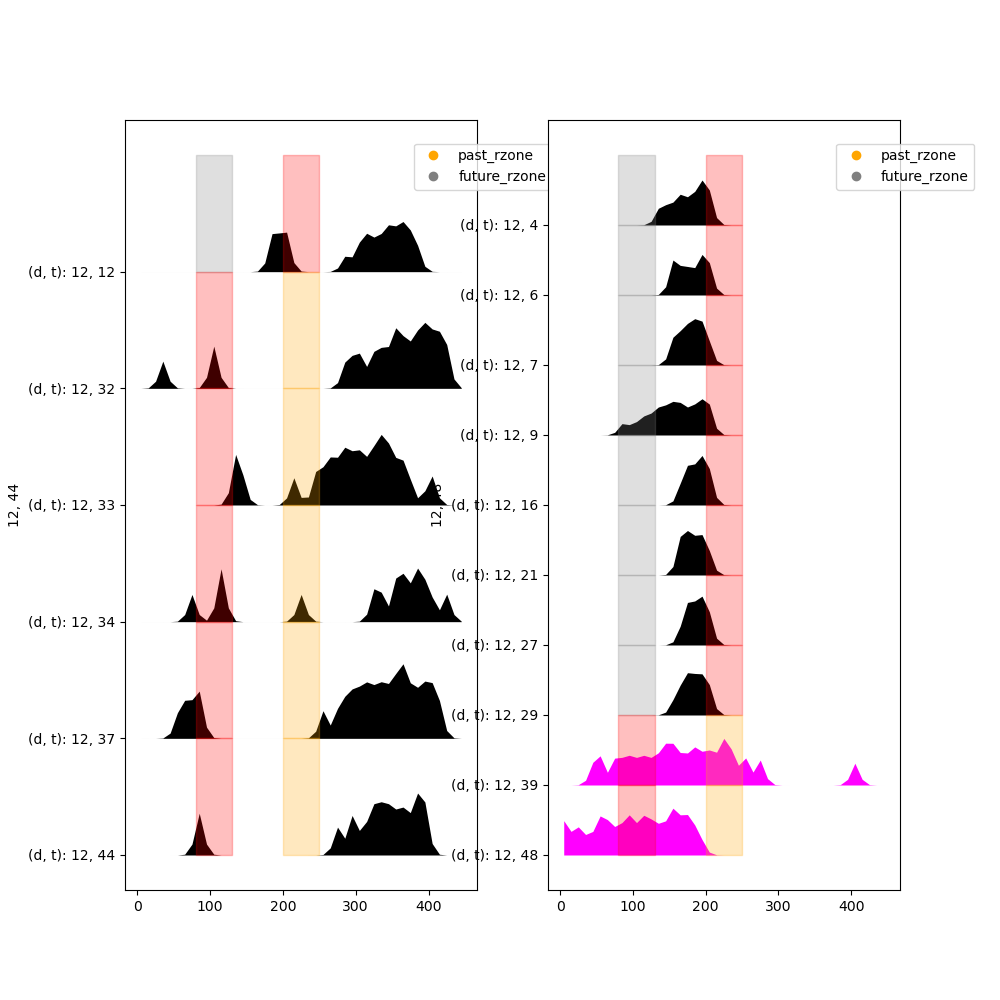

In [29]:
fig, axs = plt.subplots(ncols = 2, figsize = (10, 10))
day_key = list(outliers.keys())[0]
labels = list(outliers[day_key].keys())

plot_raster_from_licks(licks_na_free[trials_na_free.idx.isin(outliers[day_key][labels[0]].idx.values)], 
                       trials_na_free.loc[trials_na_free.idx.isin(outliers[day_key][labels[0]].idx.values)],ax = axs[0] )
plot_raster_from_licks(licks_na_free[trials_na_free.idx.isin(outliers[day_key][labels[1]].idx.values)], 
                       trials_na_free.loc[trials_na_free.idx.isin(outliers[day_key][labels[1]].idx.values)],ax = axs[1] )

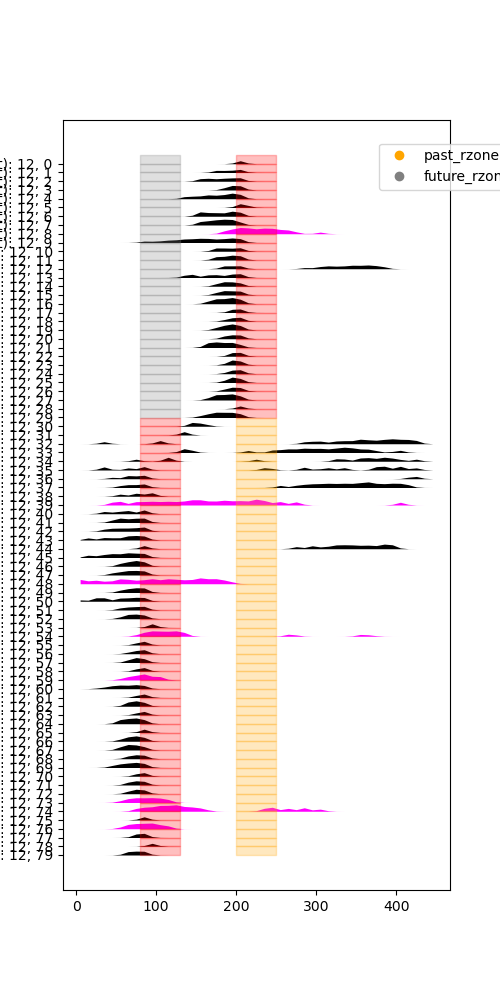

In [30]:
fig, ax = plt.subplots(figsize = (5, 10))

lick_slicer = (trials_na_free.animal == animal)&(trials_na_free.day == day)


plot_raster_from_licks(licks_na_free[lick_slicer], 
                       trials_na_free.loc[lick_slicer],ax = ax )

In [38]:
import h5py
file_name = '/data/dave/sosa_data_h5/hdf5_conversion'

f= h5py.File(file_name, "r")

In [39]:
def recreate_trial_meta_df(hdf5_group):
    data_dict = {key:hdf5_group[key][:] for key in hdf5_group.keys()}
    for k,vals in data_dict.items():
        if vals.dtype == np.dtypes.ObjectDType:
            data_dict[k] = np.asarray([v.decode() for v in vals])
    return pd.DataFrame.from_dict(data_dict)
        

In [40]:
f.keys()

<KeysViewHDF5 ['GCAMP11', 'GCAMP12', 'GCAMP13', 'GCAMP14', 'GCAMP15', 'GCAMP17', 'GCAMP18', 'GCAMP19', 'GCAMP3', 'GCAMP4', 'GCAMP7']>

In [34]:
animal

'GCAMP14'

In [35]:
trials_na_free.loc[(trials_na_free.animal == animal)&(trials_na_free.day == day)]

,Unnamed: 0,idx,day,trial,reward_zone_start,reward_zone_end,swap_zone_start,swap_zone_end,trial_type,swap_type,omit,animal
3835,0,3885,12,0,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14
3836,1,3886,12,1,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14
3837,2,3887,12,2,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14
3838,3,3888,12,3,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14
3839,4,3889,12,4,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14
...,...,...,...,...,...,...,...,...,...,...,...,...
3910,75,3960,12,75,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP14
3911,76,3961,12,76,80,130,200.0,250.0,post_swap,swap_proximal,True,GCAMP14
3912,77,3962,12,77,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP14
3913,78,3963,12,78,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP14


In [36]:
metadata

,Unnamed: 0,idx,day,trial,reward_zone_start,reward_zone_end,swap_zone_start,swap_zone_end,trial_type,swap_type,omit,animal,hdb_labels
3835,0,3885,12,0,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14,12
3836,1,3886,12,1,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14,11
3837,2,3887,12,2,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14,5
3838,3,3888,12,3,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14,11
3839,4,3889,12,4,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3910,75,3960,12,75,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP14,1
3911,76,3961,12,76,80,130,200.0,250.0,post_swap,swap_proximal,True,GCAMP14,10
3912,77,3962,12,77,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP14,3
3913,78,3963,12,78,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP14,1


In [41]:
def tm_zscore(tm):
    #append trials along axis 0
    resh = tm.reshape(-1, tm.shape[-1])
    std = np.std(resh, axis = 0)
    mean = np.mean(resh, axis = 0)

    return (tm - mean) / std



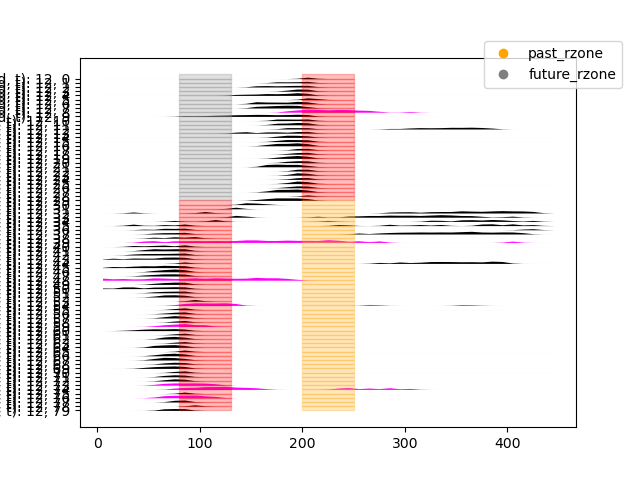

In [42]:
hd5_animal = str(animal)
hd5_day = str(day) 

hd5_df = recreate_trial_meta_df(f[hd5_animal][hd5_day]['trial_metadata'])




cols_to_map = ['idx', 'hdb_labels', 'swap_zone_start', 'swap_zone_end']
idxs = metadata.loc[(metadata.animal == animal)&(metadata.day == day), cols_to_map+['trial']]

for col in ['idx', 'hdb_labels', 'swap_zone_start', 'swap_zone_end']:
    hd5_df[col] = hd5_df['trial'].map(idxs.set_index('trial')[col])



fig, ax = plt.subplots()
plot_raster_from_licks(f[hd5_animal][hd5_day]['lick_data']['smoothed_licks'][[i for i in range(len(hd5_df))]], hd5_df, ax)
# plot_raster_from_licks(f[animal][day]['lick_data']['smoothed_licks'][[9,10,29,30,34,35,55]], df.iloc[[9,10,29,30,34,35,55]], ax)


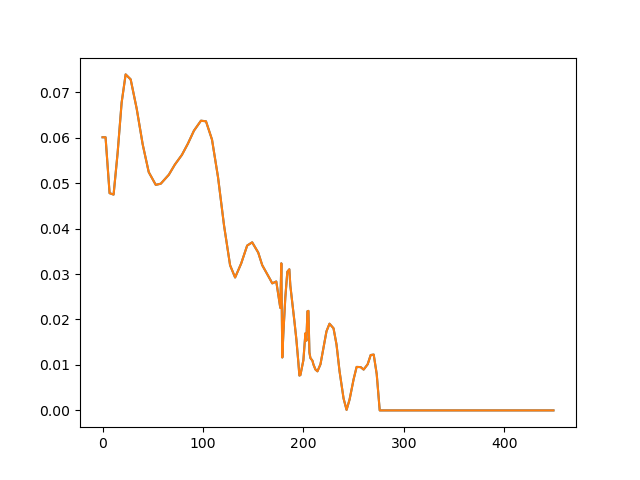

In [43]:
neural_trials = f[hd5_animal][hd5_day]['neural_events_trial_matrix'][:]

resh = neural_trials.reshape(-1, neural_trials.shape[-1])
resh.mean(axis=0).shape

fig, ax =plt.subplots()
ax.plot(resh[450:900, 0])
ax.plot(neural_trials[1,:,0])

In [ ]:
def add_default_rzone_lines(ax, color = 'white', alpha = 0.5):
    for loc in [80, 200, 320]:
        ax.vlines(x = [loc], ymin=0, ymax=449, color = color, alpha = alpha, linestyles= '--')
        ax.hlines(y = [loc], xmin = 0, xmax = 449, color = color, alpha = alpha,  linestyles= '--')



In [123]:
neural_bins = np.arange(1, 451, 1)

Text(0.5, 1.0, 'speed')

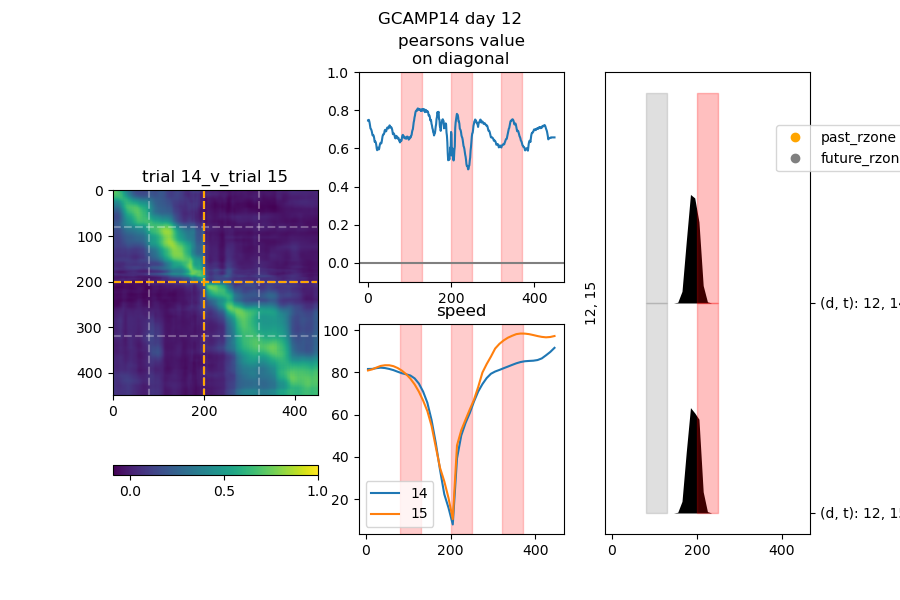

In [103]:
trial_1 , trial_2 = sorted([15,14])

# trial_1 = 'mean_pre'
# pv1 = f['GCAMP13']['14']['neural_events_trial_matrix'][5:25].mean(axis = 0)
pv1 = f[hd5_animal][hd5_day]['neural_events_trial_matrix'][trial_1,:]
pv2 = f[hd5_animal][hd5_day]['neural_events_trial_matrix'][trial_2,:]

corr_mats, corr_labels = pf.correlate_two_pop_vectors(pv1, pv2, pv1_name=f'trial {trial_1}', pv2_name=f'trial {trial_2}')

fig = plt.figure(figsize = (9,6))
fig.suptitle(f"{animal} day {day}")
axes_dict = fig.subplot_mosaic([['corr_mat', 'pearsons_diag', 'lick_raster'],
                                    ['corr_mat', 'speed', 'lick_raster'],
                                    ],
                                height_ratios = [1.0,1.0],
                                width_ratios = [1.0,1.0, 1.0])

r_zone1 = hd5_df.iloc[0]['reward_zone_start']
r_zone2 = hd5_df.iloc[trial_2]['reward_zone_start']

clim = (min([m.min() for m in corr_mats]), max([m.max() for m in corr_mats]))

corr_mat = corr_mats[-1]


im = axes_dict['corr_mat'].imshow(corr_mat, clim = clim)
add_default_rzone_lines(axes_dict['corr_mat'], alpha = 0.3)

axes_dict['corr_mat'].vlines(x = [r_zone1], ymin=0, ymax=449, color = 'white', linestyles= '--')
axes_dict['corr_mat'].hlines(y = [r_zone1], xmin = 0, xmax = 449, color = 'white', linestyles= '--')

axes_dict['corr_mat'].vlines(x = [r_zone2], ymin = 0, ymax = 449, color = 'orange', linestyles= '--')
axes_dict['corr_mat'].hlines(y = [r_zone2], xmin = 0, xmax = 449, color = 'orange', linestyles= '--')


axes_dict['corr_mat'].set_title(corr_labels[-1])

axes_dict['pearsons_diag'].plot(np.diag(corr_mats[-1]))
axes_dict['pearsons_diag'].set_ylim((-0.1,1))
axes_dict['pearsons_diag'].axhline(y=0, color = 'gray')
for st in [80, 200, 320]:
    axes_dict['pearsons_diag'].axvspan(st, st+50, color = 'red', alpha = 0.2)
    axes_dict['speed'].axvspan(st, st+50, color = 'red', alpha = 0.2)

plot_raster_from_licks(f[hd5_animal][hd5_day]['lick_data']['smoothed_licks'][[trial_1, trial_2]], hd5_df.iloc[[trial_1, trial_2]], axes_dict['lick_raster'])
axes_dict['lick_raster'].tick_params(right=True, labelright=True, left=False, labelleft=False)
axes_dict['pearsons_diag'].set_title('pearsons value\non diagonal')
fig.colorbar(im, ax=axes_dict['corr_mat'], location = 'bottom')

speeds = f[hd5_animal][hd5_day]['speed']['speed'][[trial_1, trial_2]]
speed_bins = f[hd5_animal][hd5_day]['speed']['bin_center'][:]
for trial, speed in zip([trial_1, trial_2], speeds):
    axes_dict['speed'].plot(speed_bins, speed, label = trial)
axes_dict['speed'].legend()
axes_dict['speed'].set_title('speed')

In [ ]:
def get_data_trials_by_idx(data, data_meta_df, idx_list):
    return data[data_meta_df.idx.isin(idx_list).values]

def get_pop_vec_similarity_across_array(pv_array, pv_comparitor = None):
    '''if comparing against self, compare trial to mean of all other trials. that is, leave out each 
        individual trial from the mean. '''
    if pv_comparitor is not None:
        
        corr_mats, corr_labels = pf.correlate_two_pop_vectors(pv_comparitor, pv_array[0], pv1_name=f'_', pv2_name=f'_')
        corr_mat = corr_mats[-1]
        out = np.zeros(shape = (pv_array.shape[0], corr_mat.shape[0], corr_mat.shape[1]))
        out[0] = corr_mat
        for i, pv in enumerate(pv_array[1:]):
            corr_mats, corr_labels = pf.correlate_two_pop_vectors(pv_comparitor, pv, pv1_name=f'_', pv2_name=f'_')
            out[i+1] = corr_mats[-1]

    else:
        
        out = np.zeros(shape = (pv_array.shape[0], pv_array.shape[1], pv_array.shape[1]))
        pv_ma_array = np.ma.array(pv_array, mask = False)
        for i in range(pv_array.shape[0]):
            pv_ma_array.mask[i] = True
            pv = pv_array[i]

            pv_comparitor = pv_ma_array.mean(axis = 0)
            corr_mats, corr_labels = pf.correlate_two_pop_vectors(pv_comparitor, pv, pv1_name=f'_', pv2_name=f'_')
            out[i]= corr_mats[-1]
            pv_ma_array.mask[i] = False

    return out

def velocity_binwise_correlation(speed_tm):
    '''take a speed tm (trials, track_position) and calculate the pearsons across trials at each bin'''
    np.corrcoef(speed_tm.T)
    

    return out





In [49]:
hd5_df.hdb_labels.value_counts()

0     11
9     10
5      7
3      7
12     6
11     6
4      6
6      5
8      5
10     5
2      4
7      4
1      4
Name: hdb_labels, dtype: int64

In [50]:
np.where(metadata.trial.diff()>1)

(array([], dtype=int64),)

In [51]:
metadata.hdb_labels.value_counts()

0     11
9     10
5      7
3      7
12     6
11     6
4      6
6      5
8      5
10     5
2      4
7      4
1      4
Name: hdb_labels, dtype: int64

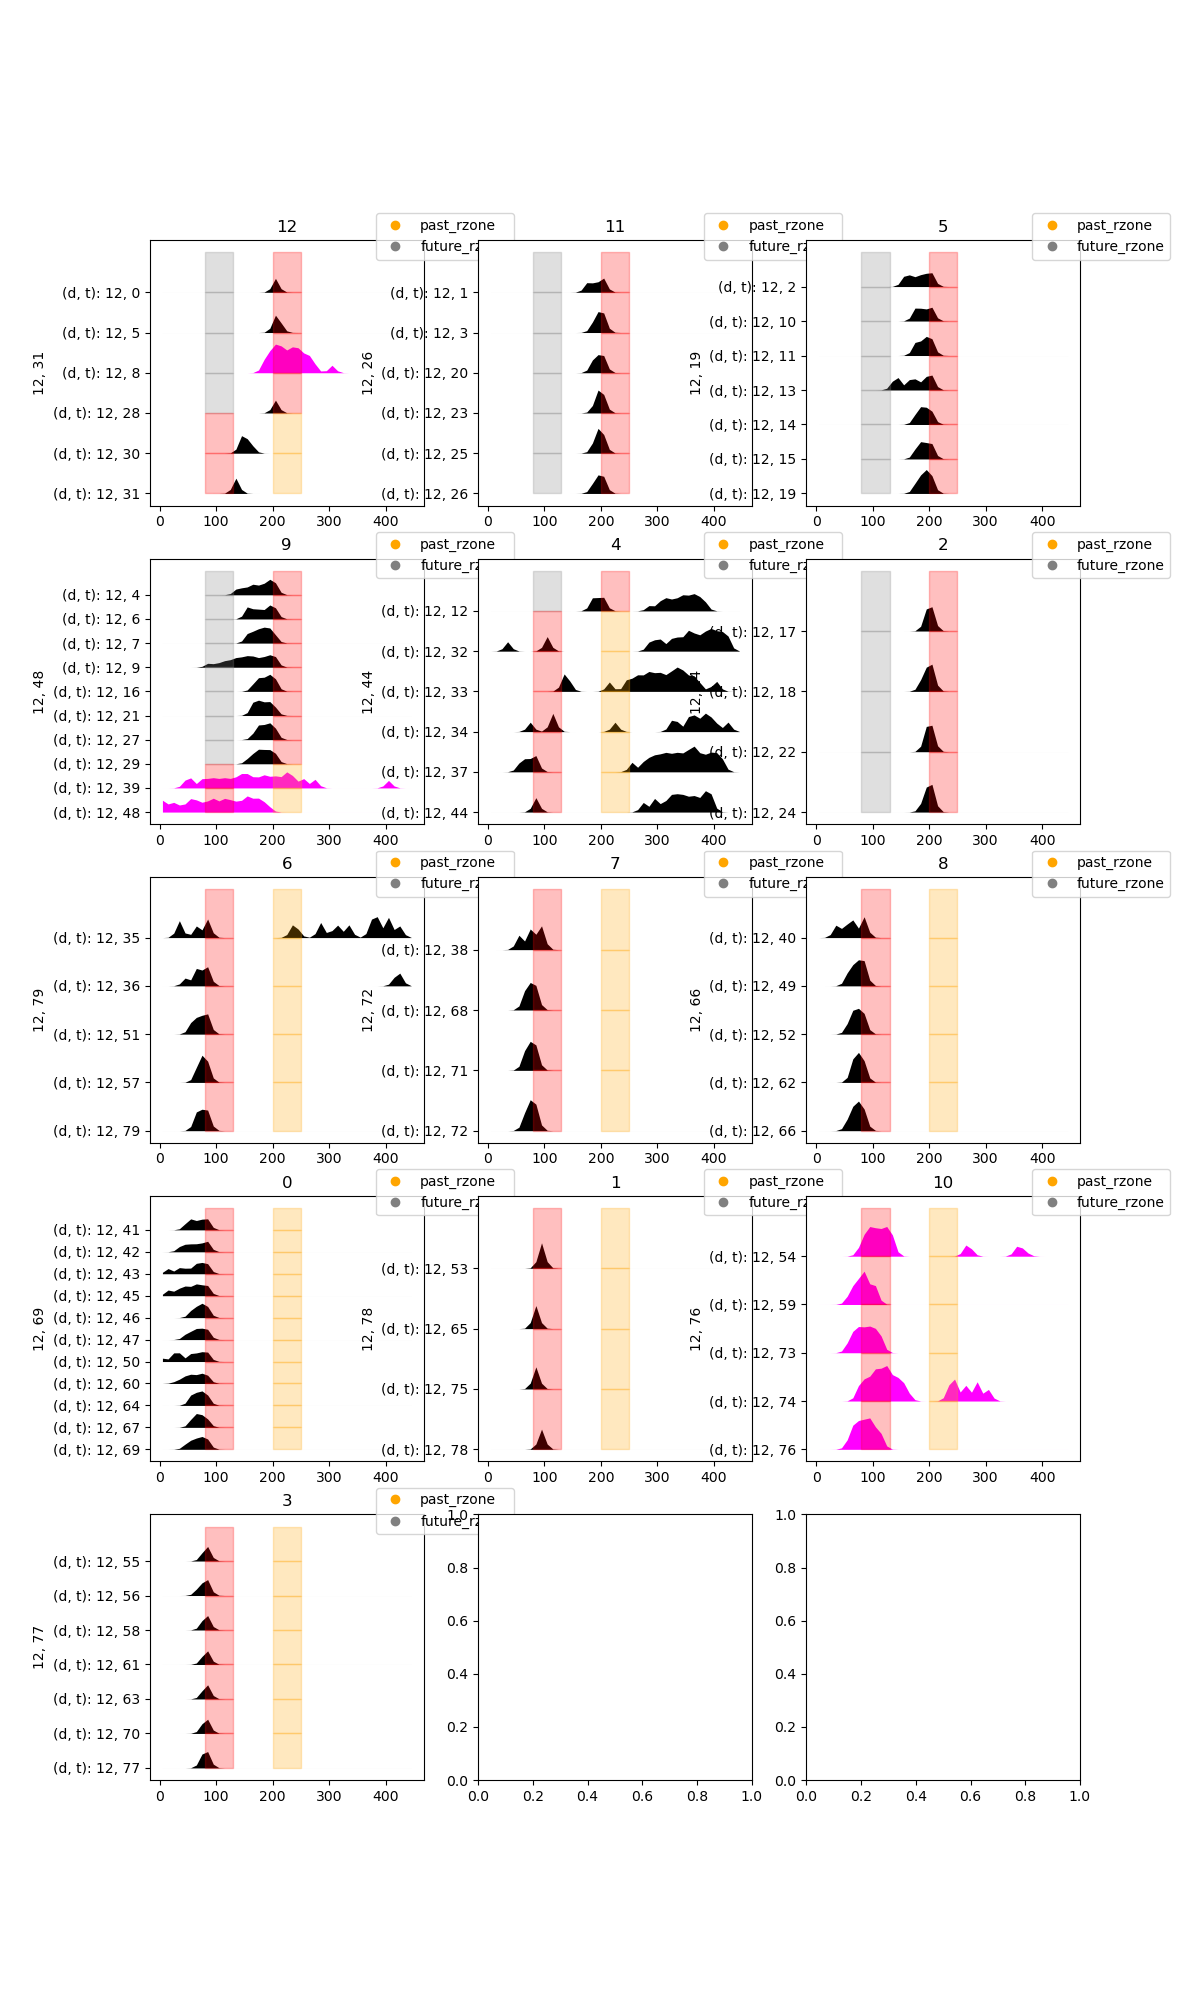

In [52]:
labels = hd5_df.hdb_labels.unique()

ncols = 3
nrows = int(np.ceil(len(labels)/ncols))
fig, axs = plt.subplots(ncols = ncols, nrows = nrows, figsize = (4*ncols, 4*nrows))

for ax, label in zip(axs.ravel(), labels):
    hd5_df_from_label = hd5_df.loc[hd5_df.idx.isin(metadata.loc[metadata.hdb_labels == label, 'idx'])] 
    lick_from_label = get_data_trials_by_idx(f[hd5_animal][hd5_day]['lick_data']['smoothed_licks'][:], hd5_df, metadata.loc[metadata.hdb_labels == label, 'idx'])
    plot_raster_from_licks(lick_from_label, hd5_df_from_label, ax)
    ax.set_title(label)



In [53]:
# neural_trials = f[hd5_animal][hd5_day]['neural_events_trial_matrix'][:]
# label = 0

# hd5_df_from_label = hd5_df.loc[hd5_df.idx.isin(metadata.loc[metadata.hdb_labels == label, 'idx'])] 

# pv_from_label = get_data_trials_by_idx(neural_trials, hd5_df, metadata.loc[metadata.hdb_labels == label, 'idx'])
# lick_from_label = get_data_trials_by_idx(f[hd5_animal][hd5_day]['lick_data']['smoothed_licks'][:], hd5_df, metadata.loc[metadata.hdb_labels == label, 'idx'])
# all_label_pearsons = get_pop_vec_similarity_across_array(pv_from_label)
# fig, rast_ax = plt.subplots(ncols = 3, figsize = (6,4))
# plot_raster_from_licks(lick_from_label, hd5_df_from_label, rast_ax[0])
# mean_pear = all_label_pearsons.mean(axis = 0)
# rast_ax[1].imshow(all_label_pearsons.mean(axis = 0), clim = (-0.1,1))
# add_default_rzone_lines(rast_ax[1], alpha = 0.3)
# rast_ax[2].plot( np.diag(mean_pear))
# rast_ax[2].set_ylim((-0.1, 1))
# rast_ax[1].plot()
# nrows = int(np.ceil(len(all_label_pearsons)/4))
# fig, axs = plt.subplots(ncols = 4, nrows = nrows, figsize = (8, 2*nrows))
# for ax, pear, trial in zip(axs.ravel(), all_label_pearsons, hd5_df_from_label.trial):
#     add_default_rzone_lines(ax, alpha = 0.3)
#     ax.imshow(pear, clim = (-0.1, 1))
#     ax.set_title(trial)



In [54]:
metadata

,Unnamed: 0,idx,day,trial,reward_zone_start,reward_zone_end,swap_zone_start,swap_zone_end,trial_type,swap_type,omit,animal,hdb_labels
3835,0,3885,12,0,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14,12
3836,1,3886,12,1,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14,11
3837,2,3887,12,2,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14,5
3838,3,3888,12,3,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14,11
3839,4,3889,12,4,200,250,80.0,130.0,pre_swap,swap_proximal,False,GCAMP14,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3910,75,3960,12,75,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP14,1
3911,76,3961,12,76,80,130,200.0,250.0,post_swap,swap_proximal,True,GCAMP14,10
3912,77,3962,12,77,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP14,3
3913,78,3963,12,78,80,130,200.0,250.0,post_swap,swap_proximal,False,GCAMP14,1


In [63]:
f[hd5_animal][hd5_day]['speed'].keys()

<KeysViewHDF5 ['bin_center', 'bin_edges', 'occupancy', 'speed']>

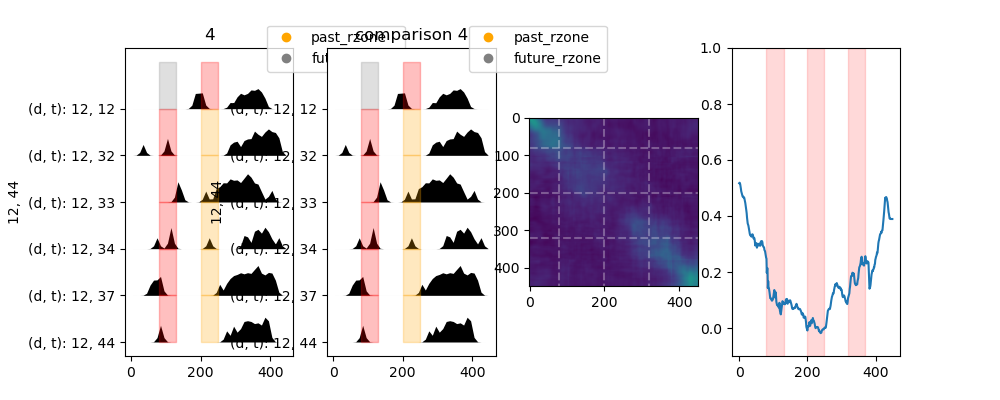

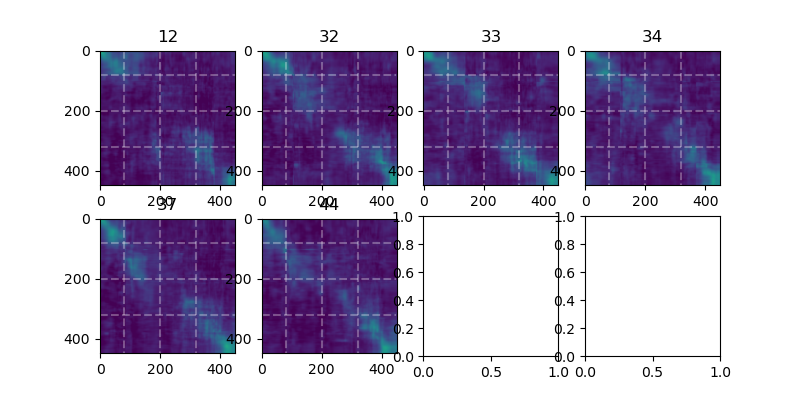

In [179]:
label = 4
comp_label = 4

neural_trials_raw = f[hd5_animal][hd5_day]['neural_events_trial_matrix'][:]
neural_trials = tm_zscore(neural_trials_raw)
hd5_df_from_label = hd5_df.loc[hd5_df.idx.isin(metadata.loc[metadata.hdb_labels == label, 'idx'])] 

pv_from_label = get_data_trials_by_idx(neural_trials, hd5_df, 
                                       metadata.loc[metadata.hdb_labels == label, 'idx'])
lick_from_label = get_data_trials_by_idx(f[hd5_animal][hd5_day]['lick_data']['smoothed_licks'][:], 
                                         hd5_df, metadata.loc[metadata.hdb_labels == label, 'idx'])

speeds_from_label = get_data_trials_by_idx(f[hd5_animal][hd5_day]['speed']['speed'][:], 
                                         hd5_df, metadata.loc[metadata.hdb_labels == label, 'idx'])
speed_bins_from_label = f[hd5_animal][hd5_day]['speed']['bin_center'][:]

comp_hd5_df_from_label = hd5_df.loc[hd5_df.idx.isin(metadata.loc[metadata.hdb_labels == comp_label, 'idx'])] 
comp_pv_from_label = get_data_trials_by_idx(neural_trials, hd5_df, 
                                            metadata.loc[metadata.hdb_labels == comp_label, 'idx'])

comp_lick_from_label = get_data_trials_by_idx(f[hd5_animal][hd5_day]['lick_data']['smoothed_licks'][:], 
                                              hd5_df, metadata.loc[metadata.hdb_labels == comp_label, 'idx'])



if label != comp_label:
    all_label_pearsons = get_pop_vec_similarity_across_array(pv_from_label, pv_comparitor=comp_pv_from_label.mean(axis = 0))
else:
    all_label_pearsons = get_pop_vec_similarity_across_array(pv_from_label)



fig, rast_ax = plt.subplots(ncols = 4, figsize = (10,4))
plot_raster_from_licks(lick_from_label, hd5_df_from_label, rast_ax[0])
rast_ax[0].set_title(label)
plot_raster_from_licks(comp_lick_from_label, comp_hd5_df_from_label, rast_ax[1])
rast_ax[1].set_title(f'comparison {comp_label}')


mean_pear = all_label_pearsons.mean(axis = 0)
rast_ax[2].imshow(all_label_pearsons.mean(axis = 0), clim = (-0.1,1))
add_default_rzone_lines(rast_ax[2], alpha = 0.3)
rast_ax[3].plot( np.diag(mean_pear))
rast_ax[3].set_ylim((-0.1, 1))
for st in [80, 200, 320]:
    rast_ax[3].axvspan(st, st+50, color = 'red', alpha = 0.15)



nrows = int(np.ceil(len(all_label_pearsons)/4))
fig, axs = plt.subplots(ncols = 4, nrows = nrows, figsize = (8, 2*nrows))
for ax, pear, trial in zip(axs.ravel(), all_label_pearsons, hd5_df_from_label.trial):
    add_default_rzone_lines(ax, alpha = 0.3)
    ax.imshow(pear, clim = (-0.1, 1))
    ax.set_title(trial)

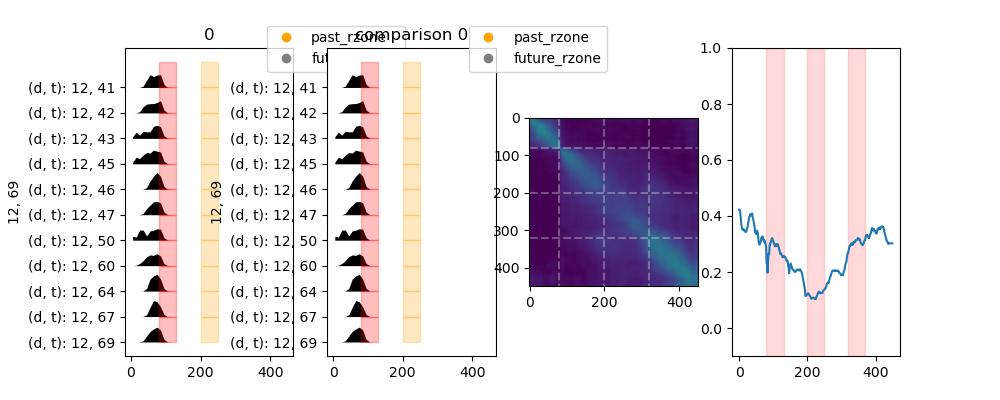

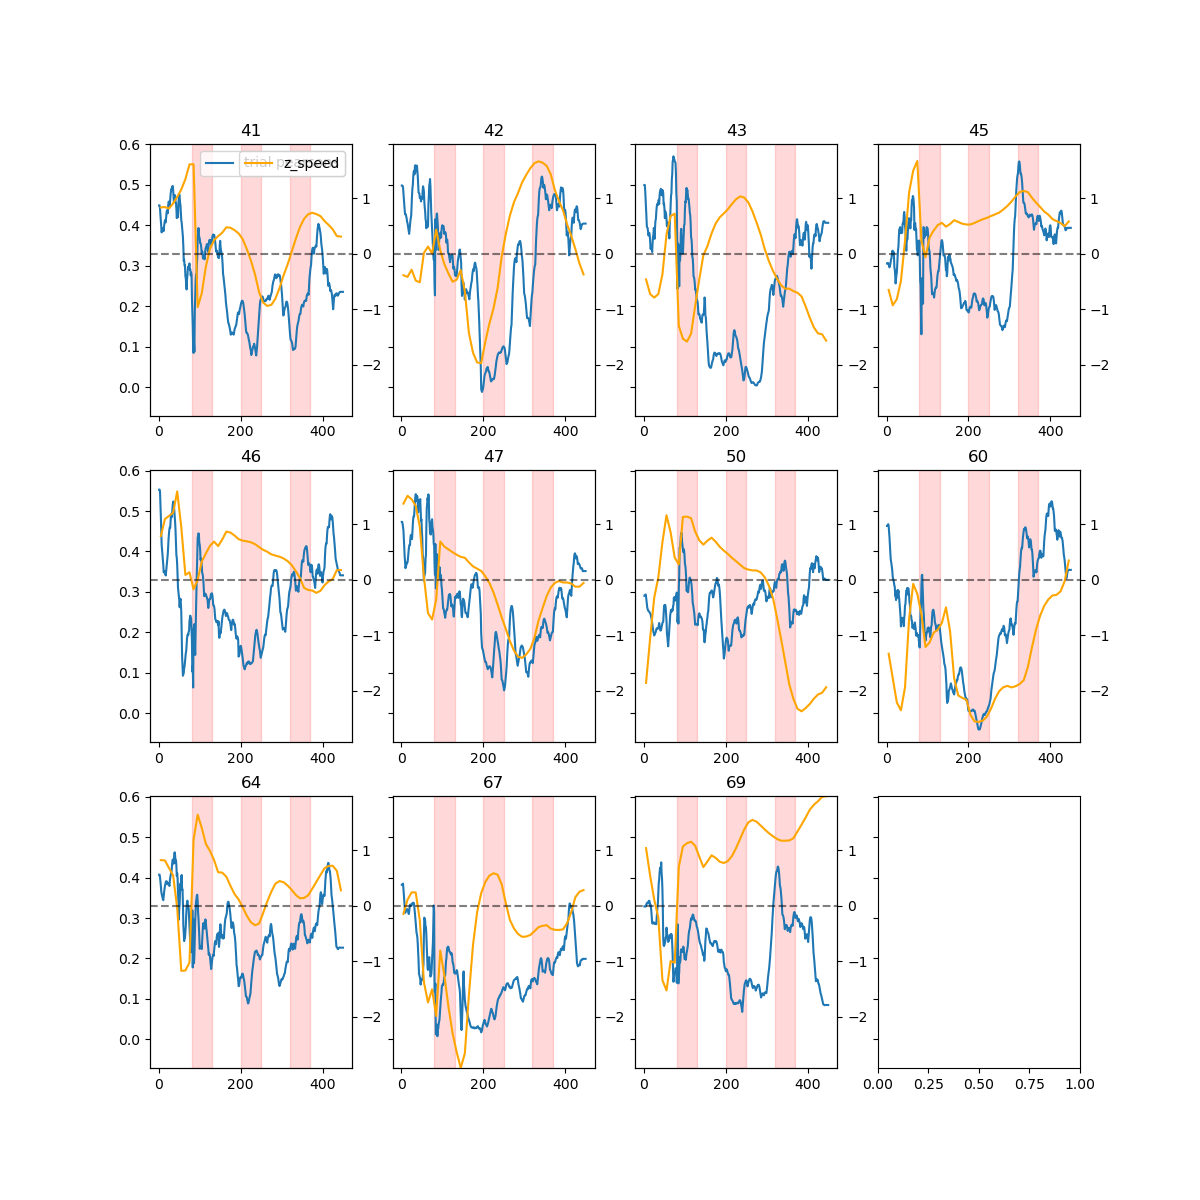

In [177]:
label = 0
comp_label = 0

neural_trials_raw = f[hd5_animal][hd5_day]['neural_events_trial_matrix'][:]
neural_trials = tm_zscore(neural_trials_raw)
hd5_df_from_label = hd5_df.loc[hd5_df.idx.isin(metadata.loc[metadata.hdb_labels == label, 'idx'])] 

pv_from_label = get_data_trials_by_idx(neural_trials, hd5_df, 
                                       metadata.loc[metadata.hdb_labels == label, 'idx'])
lick_from_label = get_data_trials_by_idx(f[hd5_animal][hd5_day]['lick_data']['smoothed_licks'][:], 
                                         hd5_df, metadata.loc[metadata.hdb_labels == label, 'idx'])

speeds_from_label = get_data_trials_by_idx(f[hd5_animal][hd5_day]['speed']['speed'][:], 
                                         hd5_df, metadata.loc[metadata.hdb_labels == label, 'idx'])

z_speeds = sts.zscore(speeds_from_label, axis = 0)

speed_bins_from_label = f[hd5_animal][hd5_day]['speed']['bin_center'][:]

comp_hd5_df_from_label = hd5_df.loc[hd5_df.idx.isin(metadata.loc[metadata.hdb_labels == comp_label, 'idx'])] 
comp_pv_from_label = get_data_trials_by_idx(neural_trials, hd5_df, 
                                            metadata.loc[metadata.hdb_labels == comp_label, 'idx'])

comp_lick_from_label = get_data_trials_by_idx(f[hd5_animal][hd5_day]['lick_data']['smoothed_licks'][:], 
                                              hd5_df, metadata.loc[metadata.hdb_labels == comp_label, 'idx'])



if label != comp_label:
    all_label_pearsons = get_pop_vec_similarity_across_array(pv_from_label, pv_comparitor=comp_pv_from_label.mean(axis = 0))
else:
    all_label_pearsons = get_pop_vec_similarity_across_array(pv_from_label)



fig, rast_ax = plt.subplots(ncols = 4, figsize = (10,4))
plot_raster_from_licks(lick_from_label, hd5_df_from_label, rast_ax[0])
rast_ax[0].set_title(label)
plot_raster_from_licks(comp_lick_from_label, comp_hd5_df_from_label, rast_ax[1])
rast_ax[1].set_title(f'comparison {comp_label}')


mean_pear = all_label_pearsons.mean(axis = 0)
rast_ax[2].imshow(all_label_pearsons.mean(axis = 0), clim = (-0.1,1))
add_default_rzone_lines(rast_ax[2], alpha = 0.3)
rast_ax[3].plot( np.diag(mean_pear))
rast_ax[3].set_ylim((-0.1, 1))
for st in [80, 200, 320]:
    rast_ax[3].axvspan(st, st+50, color = 'red', alpha = 0.15)



nrows = int(np.ceil(len(all_label_pearsons)/4))
fig, axs = plt.subplots(ncols = 4, nrows = nrows, figsize = (12, 4*nrows), sharey = True)

pears_vs_interp_z_speed = np.zeros( (len(all_label_pearsons), 450, 2) )
i = 0

for ax, pear, z_speed, trial in zip(axs.ravel(), all_label_pearsons, z_speeds, hd5_df_from_label.trial):
    
    ax.plot( neural_bins, np.diag(pear), label = 'trial pearsons')
    twin = ax.twinx()
    twin.plot(speed_bins, z_speed, color = 'orange', label = 'z_speed')
    
    twin.set_ylim((z_speeds.min(), z_speeds.max()))
    twin.axhline(y = 0, color = 'black', linestyle = '--', alpha = 0.5)
    ax.set_title(trial)
    for st in [80, 200, 320]:
        ax.axvspan(st, st+50, color = 'red', alpha = 0.15)

    # speed_interp = np.interp(neural_bins, speed_bins, z_speed)
    pears_vs_interp_z_speed[i, :,0] = np.diag(pear)
    pears_vs_interp_z_speed[i, :,1] = speed_interp
    # twin.plot(neural_bins, speed_interp, marker = '.',color = 'red', label = 'interp_speed')
    i+=1
    if i == 1:
        twin.legend()


axs[0,0].legend()

In [183]:
f[hd5_animal][hd5_day].keys()

<KeysViewHDF5 ['lick_data', 'neural_events_trial_matrix', 'rewards', 'speed', 'trial_metadata']>

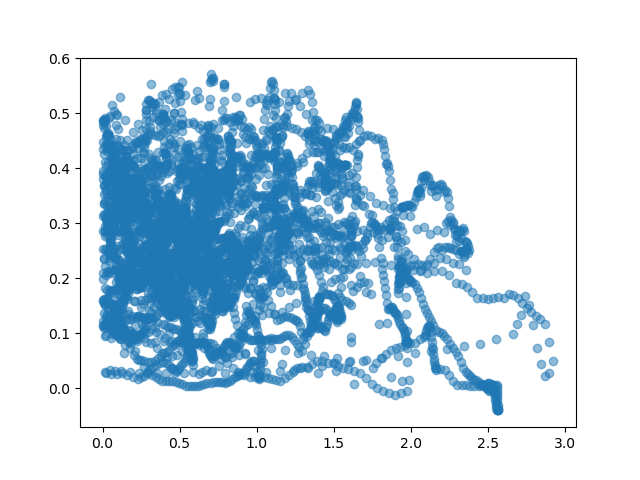

In [147]:
fig, ax = plt.subplots()
ax.scatter(np.abs(pears_vs_interp_z_speed[:,:,1]), pears_vs_interp_z_speed[:,:,0], alpha = 0.5)


In [161]:
pears_vs_interp_z_speed[:,:,1].ravel()

array([0.8325479 , 0.8325479 , 0.8325479 , ..., 1.97434909, 1.97434909,
       1.97434909])

In [158]:
np.abs(pears_vs_interp_z_speed[:,:,1]).shape

(11, 450)

<Axes: >

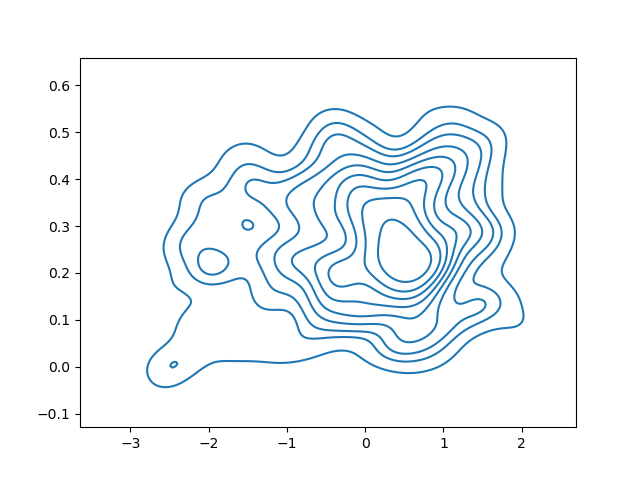

In [164]:
import seaborn as sns
fig, ax = plt.subplots()
sns.kdeplot(x = pears_vs_interp_z_speed[:,:,1].ravel(), y = pears_vs_interp_z_speed[:,:,0].ravel(), ax = ax)

/home/sosalab/miniconda3/envs/umap_env/lib/python3.11/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


[12 12 12 12 12 12 12 12 12 12]


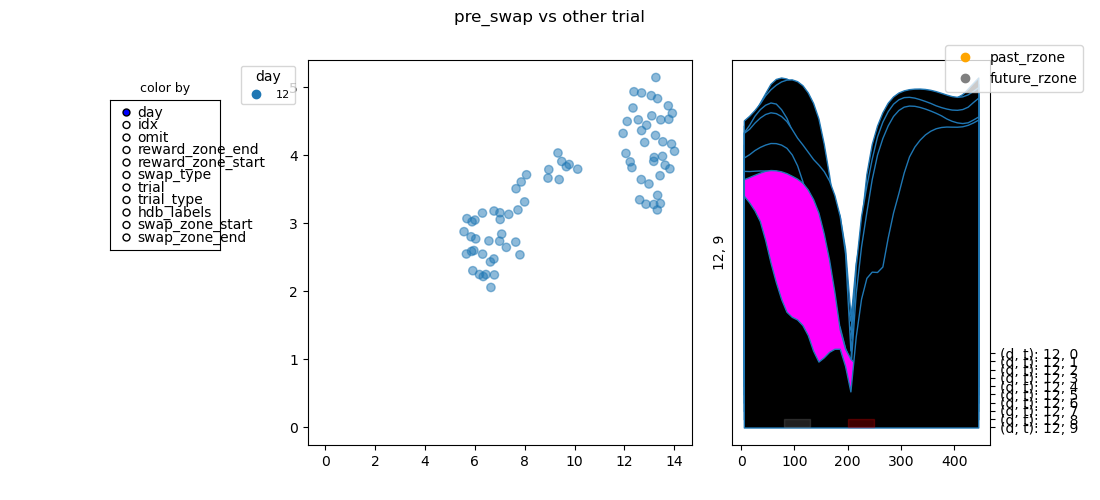

In [169]:
%matplotlib widget
import protter_plot_functions as ppf
ppf = importlib.reload(ppf)
from protter_plot_functions import add_hover, add_color_selector, ColorSelector, ColorSelectorV2#, #add_selectors
from claude_test_space import add_selectors
from protter_plot_functions import TrialPlotLinker

bin_centers = np.arange(5,455,10)

# display_slicer = (trials_na_free.animal == 'GCAMP12')&(trials_na_free.day == 14)

animal = 'GCAMP14'
day = 12

display_slicer = (trials_na_free.animal == animal) &(trials_na_free.day == day)


feats = f[hd5_animal][hd5_day]['speed']['speed'][:]
reducer = umap.UMAP(n_neighbors=len(feats), min_dist=0)

transform = reducer.fit_transform(feats)


# lick_pca = skd.PCA()
# transform = lick_pca.fit_transform(feats[:,1:])

min_samples = 3
min_cluster_size = 3
new_labels = hdbscan.HDBSCAN(
    min_samples=min_samples,
    min_cluster_size=min_cluster_size,

).fit_predict(transform)


tmp = hd5_df.copy()
tmp['hdb_labels'] = new_labels


scatter_meta = tmp
scatter_data = transform
linker = TrialPlotLinker(tmp)
raster_data = feats

fig = plt.figure(figsize = (11,5))
fig.suptitle('pre_swap vs other trial')
axes_dict = fig.subplot_mosaic([['lick_umap', 'lick_umap', 'lick_raster'],
                                    ['lick_umap','lick_umap', 'lick_raster'],
                                    ],
                                height_ratios = [3.0,2.0],
                                width_ratios = [2.0,2.0,3])

ax_umap= axes_dict['lick_umap']




scatter_1 = ax_umap.scatter(scatter_data[:,0], scatter_data[:,1], alpha = 0.5, label = 'preswap')

ax_umap.legend()


add_hover(scatter_1, scatter_meta)
color_selector = ColorSelectorV2(scatter_1,scatter_meta)

sel = add_selectors(scatter_1, linker, scatter_meta)


umap_view = ppf.ScatterView(data = transform, meta = scatter_meta, plt_obj = scatter_1)


lick_ax = axes_dict['lick_raster']
lick_ax.tick_params(right=True, labelright=True, left=False, labelleft=False)

raster_view = ppf.LickRasterView(raster_data, bin_centers, scatter_meta, lick_ax)
raster_view.link_colormaps(color_selector.get_color_linker(), )
raster_view.sort_by({'hdb_labels':'descending', 'reward_zone_start':'descending','day':'descending', 'trial':'ascending'})
color_selector.add_after_recolor_call(raster_view.update_linked_colors)

linker.add_views([umap_view, raster_view]) 
# raster_view.update(start_idx)
# umap_view.update(start_idx)


In [98]:
z_speed

(11, 45)

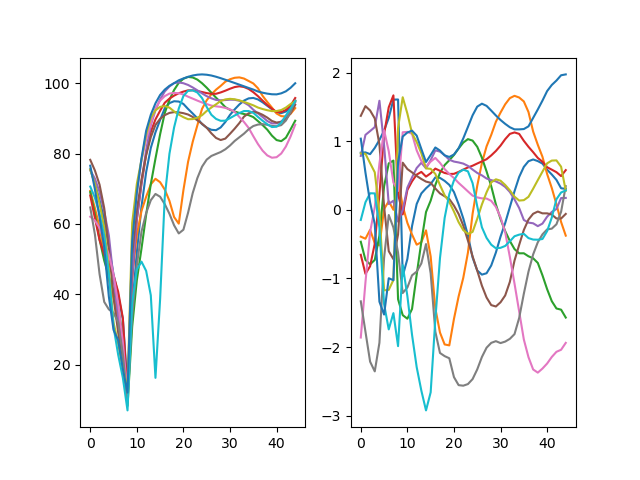

In [112]:
fig, axs = plt.subplots(ncols = 2)

# speeds_from_label = get_data_trials_by_idx(f[hd5_animal][hd5_day]['speed']['speed'][:], 
#                                          hd5_df, metadata.loc[metadata.trial_type == 'pre_swap', 'idx'])

speeds_from_label = get_data_trials_by_idx(f[hd5_animal][hd5_day]['speed']['speed'][:], 
                                         hd5_df, metadata.loc[metadata.hdb_labels == label, 'idx'])

z_speed = sts.zscore(speeds_from_label, axis = 0)
for speed in speeds_from_label:
    axs[0].plot(speed)

for speed in z_speed:
    axs[1].plot(speed)

In [85]:
pf.correlate_two_pop_vectors(speeds_from_label, speeds_from_label, 'speed1', 'speed2')[-2]

[array([[1.        , 0.86314155, 0.95801177, 0.97280282, 0.97459867,
         0.97026856, 0.91096606, 0.88719274, 0.94488497, 0.8288504 ,
         0.95493731],
        [0.86314155, 1.        , 0.83274061, 0.88638594, 0.83605661,
         0.84097233, 0.77686046, 0.96437701, 0.87843202, 0.82362304,
         0.87551709],
        [0.95801177, 0.83274061, 1.        , 0.97084231, 0.96588443,
         0.91511625, 0.92965578, 0.81370003, 0.90076498, 0.86317731,
         0.94450318],
        [0.97280282, 0.88638594, 0.97084231, 1.        , 0.97661348,
         0.94826774, 0.95855907, 0.88607071, 0.95788066, 0.81866958,
         0.97990423],
        [0.97459867, 0.83605661, 0.96588443, 0.97661348, 1.        ,
         0.97871865, 0.97195909, 0.82980394, 0.96755607, 0.80629263,
         0.97821242],
        [0.97026856, 0.84097233, 0.91511625, 0.94826774, 0.97871865,
         1.        , 0.93142813, 0.85939458, 0.98009163, 0.79412311,
         0.9708476 ],
        [0.91096606, 0.77686046, 0.92965

In [180]:
diags = {}


for i, label in enumerate(hd5_df.hdb_labels.unique()):

    neural_trials_raw = f[hd5_animal][hd5_day]['neural_events_trial_matrix'][:]
    neural_trials = tm_zscore(neural_trials_raw)
    hd5_df_from_label = hd5_df.loc[hd5_df.idx.isin(metadata.loc[metadata.hdb_labels == label, 'idx'])] 

    pv_from_label = get_data_trials_by_idx(neural_trials, hd5_df, 
                                        metadata.loc[metadata.hdb_labels == label, 'idx'])
    lick_from_label = get_data_trials_by_idx(f[hd5_animal][hd5_day]['lick_data']['smoothed_licks'][:], 
                                            hd5_df, metadata.loc[metadata.hdb_labels == label, 'idx'])

    all_label_pearsons = get_pop_vec_similarity_across_array(pv_from_label)
    mean_pear = all_label_pearsons.mean(axis = 0)
    diags[label] = np.diag(mean_pear)



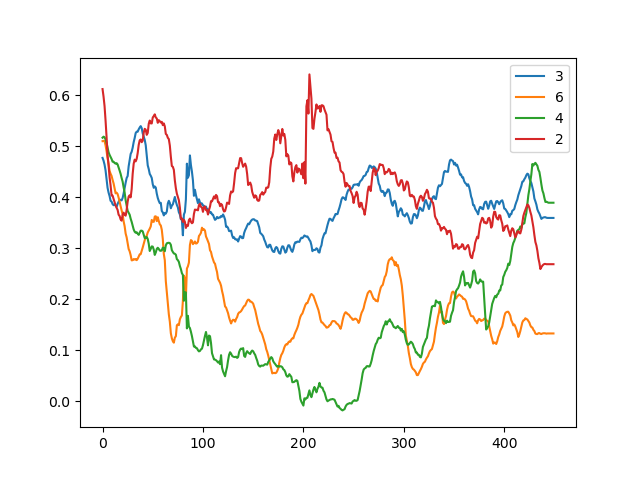

In [181]:
fig, ax = plt.subplots()
for label in [3, 6, 4, 2]:
    ax.plot(diags[label], label = label)

ax.legend()

In [ ]:
def tm_zscore(tm):
    #append trials along axis 0
    resh = tm.reshape(-1, tm.shape[-1])
    std = np.std(resh, axis = 0)
    mean = np.mean(resh, axis = 0)

    return (tm - mean) / std

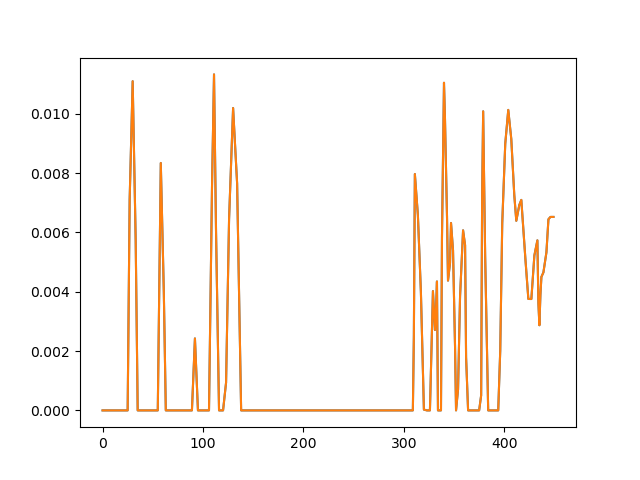

In [ ]:
resh = neural_trials.reshape(-1, neural_trials.shape[-1])
resh.mean(axis=0).shape

fig, ax =plt.subplots()
ax.plot(resh[450:900, 0])
ax.plot(neural_trials[1,:,0])

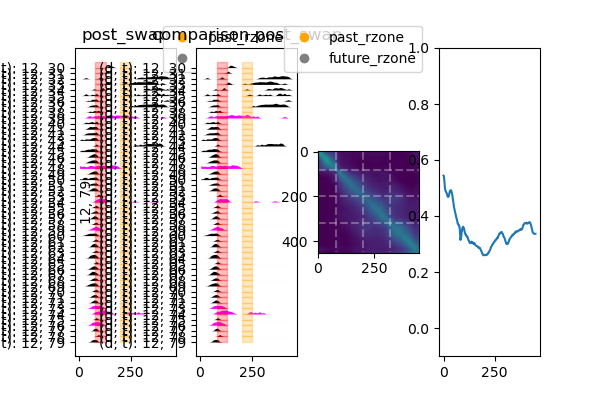

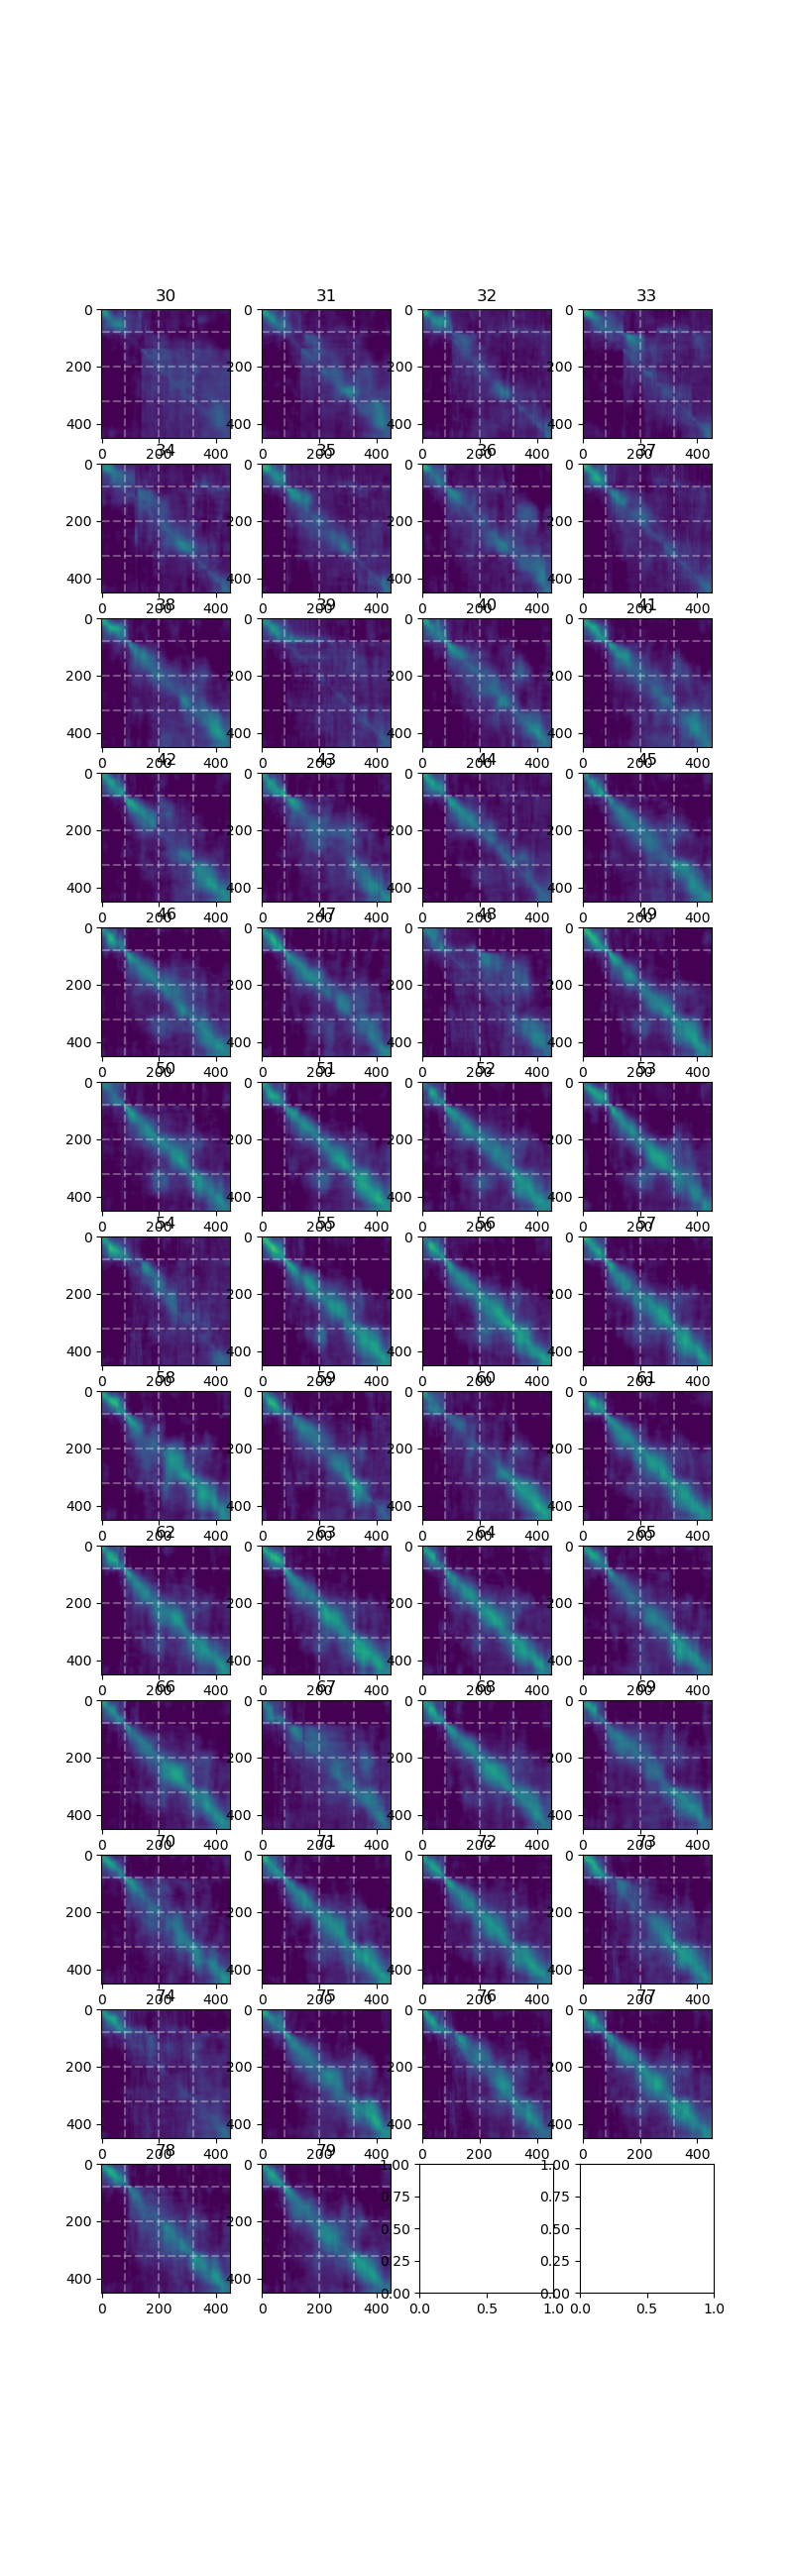

In [61]:
trial_type = 'post_swap'
comp_label = 'post_swap'

meta_slicer =( metadata.trial_type == trial_type)
hd5_df_from_label = hd5_df.loc[hd5_df.idx.isin(metadata.loc[meta_slicer, 'idx'])] 

comp_slicer = ( metadata.trial_type == comp_label)



pv_from_label = get_data_trials_by_idx(neural_trials, hd5_df, 
                                       metadata.loc[meta_slicer, 'idx'])
lick_from_label = get_data_trials_by_idx(f[hd5_animal][hd5_day]['lick_data']['smoothed_licks'][:], 
                                         hd5_df, metadata.loc[meta_slicer, 'idx'])

comp_hd5_df_from_label = hd5_df.loc[hd5_df.idx.isin(metadata.loc[comp_slicer, 'idx'])] 
comp_pv_from_label = get_data_trials_by_idx(neural_trials, hd5_df, 
                                            metadata.loc[comp_slicer, 'idx'])

comp_lick_from_label = get_data_trials_by_idx(f[hd5_animal][hd5_day]['lick_data']['smoothed_licks'][:], 
                                              hd5_df, metadata.loc[comp_slicer, 'idx'])



if label != comp_label:
    all_label_pearsons = get_pop_vec_similarity_across_array(pv_from_label, pv_comparitor=comp_pv_from_label.mean(axis = 0))
else:
    all_label_pearsons = get_pop_vec_similarity_across_array(pv_from_label)



fig, rast_ax = plt.subplots(ncols = 4, figsize = (6,4))
plot_raster_from_licks(lick_from_label, hd5_df_from_label, rast_ax[0])
rast_ax[0].set_title(trial_type)
plot_raster_from_licks(comp_lick_from_label, comp_hd5_df_from_label, rast_ax[1])
rast_ax[1].set_title(f'comparison {comp_label}')


mean_pear = all_label_pearsons.mean(axis = 0)
rast_ax[2].imshow(all_label_pearsons.mean(axis = 0), clim = (-0.1,1))
add_default_rzone_lines(rast_ax[2], alpha = 0.3)
rast_ax[3].plot( np.diag(mean_pear))
rast_ax[3].set_ylim((-0.1, 1))

nrows = int(np.ceil(len(all_label_pearsons)/4))
fig, axs = plt.subplots(ncols = 4, nrows = nrows, figsize = (8, 2*nrows))
for ax, pear, trial in zip(axs.ravel(), all_label_pearsons, hd5_df_from_label.trial):
    add_default_rzone_lines(ax, alpha = 0.3)
    ax.imshow(pear, clim = (-0.1, 1))
    ax.set_title(trial)

In [ ]:
day = '14' 
# day_meta = trials_na_free.loc[(trials_na_free.animal == animal) & (trials_na_free.day == int(day))]
# day_slicer_pre = (day_meta.trial_type == 'pre_swap')&(day_meta.omit == False)
# day_slicer_post = (day_meta.trial_type == 'post_swap')&(day_meta.omit == False)

day_meta = df
day_slicer_pre = (day_meta.trial_type == 'pre_swap')&(day_meta.omit == False)
day_slicer_post = (day_meta.trial_type == 'post_swap')&(day_meta.omit == False)

pre = np.mean(f[animal][day]['neural_events_trial_matrix'][day_slicer_pre,:], axis= 0)
post = np.mean(f[animal][day]['neural_events_trial_matrix'][day_slicer_post,:], axis=0)

fig, axs = plt.subplots(ncols = 4, nrows = 20, figsize = (9, 4*15), layout = 'constrained')
fig.suptitle(f'{animal} {day}\ntrial vs mean pre-swap (1:30)')
for i, z in enumerate(zip(axs.ravel(), f[animal][day]['neural_events_trial_matrix'][:])):

    ax, pv = z

    corr_mats, _ = pf.correlate_two_pop_vectors(pre, pv, pv1_name=f'trial {trial_1}', pv2_name=f'trial {trial_2}')

    r_zone1 = day_meta.iloc[0]['reward_zone_start']
    r_zone2 = day_meta.iloc[-1]['reward_zone_start']
    trial_type = day_meta.iloc[i]['trial_type']
    clim = (0,1)

    corr_mat = corr_mats[-1]


    im = ax.imshow(corr_mat, clim = clim)
    add_default_rzone_lines(ax, alpha = 0.1)

    ax.vlines(x = [r_zone1], ymin=0, ymax=449, color = 'gray', linestyles= '--', alpha = 0.75)
    ax.hlines(y = [r_zone1], xmin = 0, xmax = 449, color = 'gray', linestyles= '--', alpha = 0.75)

    ax.vlines(x = [r_zone2], ymin = 0, ymax = 449, color = 'orange', linestyles= '--', alpha = 0.5)
    ax.hlines(y = [r_zone2], xmin = 0, xmax = 449, color = 'orange', linestyles= '--', alpha = 0.5)


    if day_meta.iloc[i]['omit'] == True:
        ax.set_title(f'trial {i+1}, omission', color = 'magenta')
    elif trial_type == 'pre_swap':

        ax.set_title(f'trial {i+1}')
    else:
        ax.set_title(f'trial {i+1}', color = 'orange')
fig.savefig(f'{animal} {day}\ntrial vs mean pre-swap (1>30).png')

fig, axs = plt.subplots(ncols = 4, nrows = 20, figsize = (9, 4*15), layout = 'constrained')
fig.suptitle(f'{animal} {day}\ntrial vs mean post-swap (31:80)')

for i, z in enumerate(zip(axs.ravel(), f[animal][day]['neural_events_trial_matrix'][:])):

    ax, pv = z

    corr_mats, _ = pf.correlate_two_pop_vectors(post, pv, pv1_name=f'trial {trial_1}', pv2_name=f'trial {trial_2}')


    clim = (0,1)

    corr_mat = corr_mats[-1]
    trial_type = day_meta.iloc[i]['trial_type']


    im = ax.imshow(corr_mat, clim = clim)
    add_default_rzone_lines(ax, alpha = 0.1)

    ax.vlines(x = [r_zone1], ymin=0, ymax=449, color = 'gray', linestyles= '--', alpha = 0.75)
    ax.hlines(y = [r_zone1], xmin = 0, xmax = 449, color = 'gray', linestyles= '--', alpha = 0.75)

    ax.vlines(x = [r_zone2], ymin = 0, ymax = 449, color = 'orange', linestyles= '--', alpha = 0.5)
    ax.hlines(y = [r_zone2], xmin = 0, xmax = 449, color = 'orange', linestyles= '--', alpha = 0.5)


    if day_meta.iloc[i]['omit'] == True:
        ax.set_title(f'trial {i+1}, omission', color = 'magenta')
    elif trial_type == 'pre_swap':

        ax.set_title(f'trial {i+1}')
    else:
        ax.set_title(f'trial {i+1}', color = 'orange')
fig.savefig(f'{animal} {day}\ntrial vs mean post-swap (31>80).png')
    

TypeError: boolean index did not match indexed array

In [ ]:
fig.tight_layout()

In [ ]:
dvs = np.diff(speeds)
fig, ax = plt.subplots()

for trial, speed in zip([trial_1, trial_2], dvs):
    ax.plot(speed_bins[1:], speed, label = trial)

for st in [80, 200, 320]:
    ax.axvspan(st, st+50, color = 'red', alpha = 0.15)

twin = ax.twinx()
twin.plot(np.diag(corr_mats[-1]), color = 'lightgreen')
ax.axvline(x = 286, color = 'black')
ax.axhline(y = 0, color = 'gray', linestyle = '--')


In [ ]:
dvs = np.diff(speeds)
fig, ax = plt.subplots()

# for trial, speed in zip([trial_1, trial_2], speeds):
#     ax.plot(speed_bins, speed, label = trial)
ax.plot(speed_bins, speeds[0] - speeds[1])
for st in [80, 200, 320]:
    ax.axvspan(st, st+50, color = 'red', alpha = 0.2)

twin = ax.twinx()
twin.plot(np.diag(corr_mats[-1]), color = 'lime')
ax.axvline(x = 286, color = 'black')
ax.axhline(y = 0, color = 'gray', linestyle = '--')

In [ ]:
df.head()

In [ ]:
fig, ax = plt.subplots()
cell = 10
ax.plot(f[animal][day]['neural_events_trial_matrix'][trial_1,:,cell])
ax.plot(f[animal][day]['neural_events_trial_matrix'][trial_2,:,cell])

In [ ]:
import matplotlib.cm as cm
fig, ax = plt.subplots()
cell = 3
trials = np.asarray(range(15,50,1))
cmap = np.concatenate([cm.PuRd(np.linspace(0.25, 1, sum(trials<30) )), cm.BuGn(np.linspace(0.25, 1, sum(trials>=30) ))])
for i, trial in enumerate(trials):
    ax.plot(f[animal][day]['neural_events_trial_matrix'][trial,:,cell], color = cmap[i])


In [ ]:
f['GCAMP12']['10'].keys()

<KeysViewHDF5 ['lick_data', 'neural_events_trial_matrix', 'rewards', 'speed', 'trial_metadata']>

In [ ]:
f['GCAMP12']['10']['trial_metadata']['idx'].shape[0]

80

In [ ]:
for animal in f.keys():
    for d in f[animal].keys():
        if f[animal][d]['neural_events_trial_matrix'].shape[0] != f[animal][d]['trial_metadata']['idx'].shape[0]:
            print(f"{animal}: {d} tm: {f[animal][d]['neural_events_trial_matrix'].shape[0]} | {f[animal][d]['trial_metadata']['idx']} : hdf5 meta")
        sli = trials_na_free.loc[(trials_na_free.animal == animal)&(trials_na_free.day == int(d))]

        if f[animal][d]['neural_events_trial_matrix'].shape[0] != sli.shape[0]:
                    print(f"{animal}: {d} tm: {f[animal][d]['neural_events_trial_matrix'].shape[0]} | {sli.shape[0]} : csv_meta")


GCAMP11: 12 tm: 80 | 79 : csv_meta
GCAMP12: 10 tm: 80 | 79 : csv_meta
GCAMP15: 14 tm: 80 | 78 : csv_meta
GCAMP15: 5 tm: 80 | 74 : csv_meta
GCAMP17: 3 tm: 80 | 79 : csv_meta
GCAMP18: 3 tm: 80 | 76 : csv_meta
GCAMP3: 10 tm: 90 | 89 : csv_meta
GCAMP3: 12 tm: 80 | 79 : csv_meta
GCAMP4: 10 tm: 80 | 79 : csv_meta
GCAMP4: 14 tm: 80 | 45 : csv_meta
GCAMP4: 7 tm: 80 | 71 : csv_meta
GCAMP7: 8 tm: 100 | 99 : csv_meta


In [ ]:
f.close()